In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.3f}".format)

WORKING_DIR = Path.cwd()
PROJECT_ROOT = (
    WORKING_DIR.parent
    if WORKING_DIR.name == "notebooks"
    else WORKING_DIR
)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
INPUT_PATH = PROCESSED_DIR / "online_retail_cleaned.parquet"

assert INPUT_PATH.is_file(), f"File not found: {INPUT_PATH}"

df = pd.read_parquet(INPUT_PATH, engine="pyarrow")

assert df.shape == (541909, 31)
assert df["SourceRowID"].is_unique
assert pd.api.types.is_datetime64_any_dtype(df["InvoiceDate"])

revenue_check = pd.Series({
    "Gross product revenue": df.loc[
        df["IsProductSale"], "Revenue"
    ].sum(),
    "Product cancellation value": -df.loc[
        df["IsProductCancellation"], "Revenue"
    ].sum(),
    "Net product revenue": df.loc[
        df["IsNetProductRevenueEligible"], "Revenue"
    ].sum()
})

np.testing.assert_allclose(
    revenue_check.to_numpy(),
    [10247219.323, 475901.160, 9771318.163],
    rtol=0,
    atol=0.000001
)

print(f"Loaded: {INPUT_PATH.name}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Coverage: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
display(revenue_check.to_frame("value"))
print("Analysis input validation passed.")

Loaded: online_retail_cleaned.parquet
Rows: 541,909 | Columns: 31
Coverage: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


,value
Gross product revenue,"10,247,219.323"
Product cancellation value,"475,901.160"
Net product revenue,"9,771,318.163"


Analysis input validation passed.


,GrossRevenue,Orders,CancellationValue,NetRevenue,GrossAOV,IsPartialMonth,NetMoM_pct
YearMonth,,,,,,,
2010-12,"775,638.360",1550,"17,547.860","758,090.500",500.412,False,NaN
2011-01,"670,380.240",1081,"91,525.050","578,855.190",620.148,False,-23.643
2011-02,"507,799.870",1093,"8,335.520","499,464.350",464.593,False,-13.715
2011-03,"689,833.510",1440,"10,504.300","679,329.210",479.051,False,36.012
2011-04,"515,377.991",1235,"33,316.060","482,061.931",417.310,False,-29.039
2011-05,"739,953.000",1668,"8,948.230","731,004.770",443.617,False,51.641
2011-06,"737,558.980",1525,"13,713.840","723,845.140",483.645,False,-0.979
2011-07,"688,219.341",1452,"11,407.260","676,812.081",473.980,False,-6.498
2011-08,"724,216.500",1339,"22,926.570","701,289.930",540.864,False,3.617


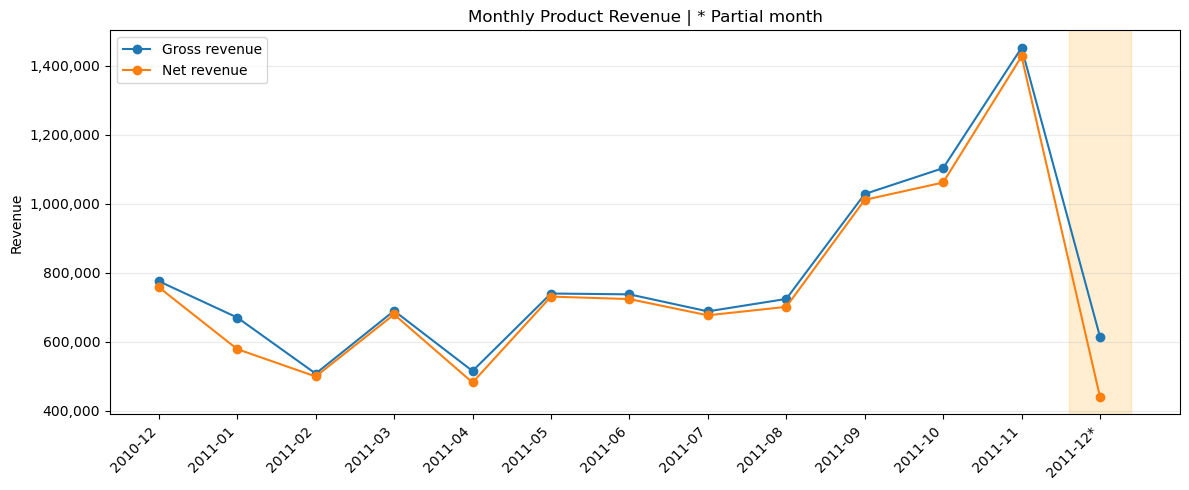

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

sales = df.loc[df["IsProductSale"]].copy()
cancellations = df.loc[df["IsProductCancellation"]].copy()

monthly = (
    sales.groupby("YearMonth")
    .agg(
        GrossRevenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .join(
        cancellations.groupby("YearMonth")["Revenue"]
        .sum()
        .mul(-1)
        .rename("CancellationValue"),
        how="outer"
    )
    .fillna(0)
    .sort_index()
)

monthly["NetRevenue"] = (
    monthly["GrossRevenue"] - monthly["CancellationValue"]
)
monthly["GrossAOV"] = (
    monthly["GrossRevenue"] / monthly["Orders"].replace(0, np.nan)
)

months = pd.PeriodIndex(monthly.index, freq="M")
coverage_start = df["InvoiceDate"].min().normalize()
coverage_end = df["InvoiceDate"].max().normalize()

monthly["IsPartialMonth"] = (
    (months.start_time.normalize() < coverage_start)
    | (months.end_time.normalize() > coverage_end)
)

comparable = (
    ~monthly["IsPartialMonth"]
    & ~monthly["IsPartialMonth"].shift(1, fill_value=True)
)

monthly["NetMoM_pct"] = (
    monthly["NetRevenue"]
    .pct_change(fill_method=None)
    .mul(100)
    .where(comparable)
)

np.testing.assert_allclose(
    monthly[["GrossRevenue", "CancellationValue", "NetRevenue"]]
    .sum()
    .to_numpy(),
    revenue_check.to_numpy(),
    rtol=0,
    atol=0.000001
)
assert monthly["Orders"].sum() == sales["InvoiceNo"].nunique()

display(monthly)

x = np.arange(len(monthly))
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, monthly["GrossRevenue"], marker="o", label="Gross revenue")
ax.plot(x, monthly["NetRevenue"], marker="o", label="Net revenue")

for position in np.flatnonzero(monthly["IsPartialMonth"].to_numpy()):
    ax.axvspan(position - 0.4, position + 0.4, color="orange", alpha=0.18)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"{month}*" if partial else month
        for month, partial in zip(monthly.index, monthly["IsPartialMonth"])
    ],
    rotation=45,
    ha="right"
)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Monthly Product Revenue | * Partial month")
ax.set_ylabel("Revenue")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

,Orders,GrossAOV,OrdersMoM_pct,AOVMoM_pct,GrossChange,OrderCountContribution,AOVContribution
YearMonth,,,,,,,
2011-01,1081,620.148,-30.258,23.928,"-105,258.120","-262,771.338","157,513.218"
2011-02,1093,464.593,1.110,-25.084,"-162,580.370","6,508.446","-169,088.816"
2011-03,1440,479.051,31.747,3.112,"182,033.640","163,722.198","18,311.442"
2011-04,1235,417.310,-14.236,-12.888,"-174,455.519","-91,877.019","-82,578.500"
2011-05,1668,443.617,35.061,6.304,"224,575.009","186,390.700","38,184.309"
2011-06,1525,483.645,-8.573,9.023,"-2,394.020","-66,299.243","63,905.223"
2011-07,1452,473.980,-4.787,-1.998,"-49,339.639","-34,953.331","-14,386.308"
2011-08,1339,540.864,-7.782,14.111,"35,997.159","-57,338.684","93,335.843"
2011-09,1818,565.633,35.773,4.580,"304,103.881","265,005.906","39,097.975"


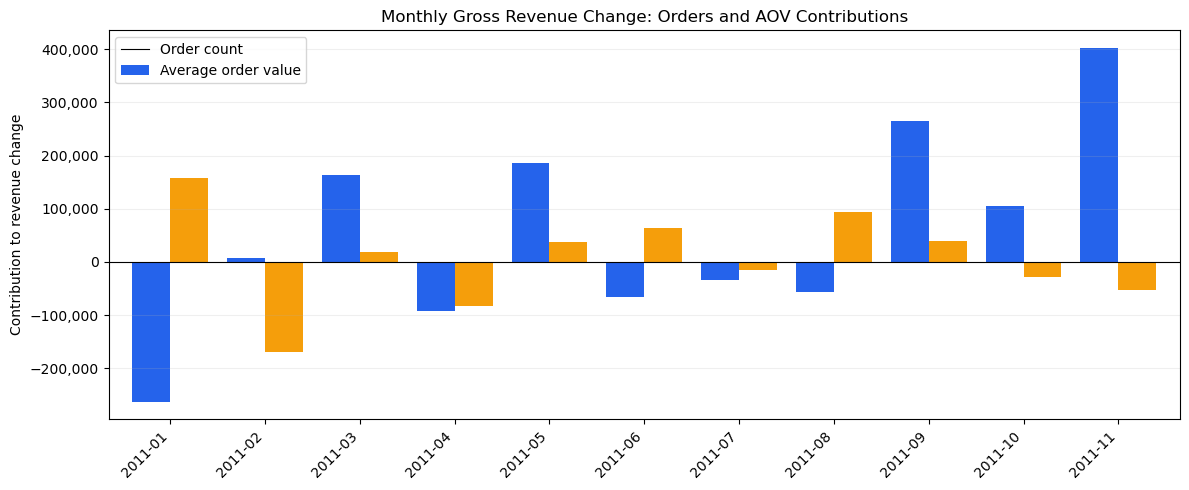

In [3]:
drivers = monthly.loc[~monthly["IsPartialMonth"]].copy()

previous_orders = drivers["Orders"].shift(1)
previous_aov = drivers["GrossAOV"].shift(1)

drivers["GrossChange"] = drivers["GrossRevenue"].diff()
drivers["OrdersMoM_pct"] = drivers["Orders"].pct_change().mul(100)
drivers["AOVMoM_pct"] = drivers["GrossAOV"].pct_change().mul(100)

drivers["OrderCountContribution"] = (
    (drivers["Orders"] - previous_orders)
    * (drivers["GrossAOV"] + previous_aov)
    / 2
)

drivers["AOVContribution"] = (
    (drivers["GrossAOV"] - previous_aov)
    * (drivers["Orders"] + previous_orders)
    / 2
)

valid = drivers["GrossChange"].notna()

np.testing.assert_allclose(
    drivers.loc[valid, "OrderCountContribution"]
    + drivers.loc[valid, "AOVContribution"],
    drivers.loc[valid, "GrossChange"],
    rtol=0,
    atol=0.000001
)

display(
    drivers.loc[valid, [
        "Orders", "GrossAOV", "OrdersMoM_pct", "AOVMoM_pct",
        "GrossChange", "OrderCountContribution", "AOVContribution"
    ]]
)

ax = drivers.loc[
    valid, ["OrderCountContribution", "AOVContribution"]
].plot.bar(
    figsize=(12, 5),
    color=["#2563EB", "#F59E0B"],
    width=0.8
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Monthly Gross Revenue Change: Orders and AOV Contributions")
ax.set_ylabel("Contribution to revenue change")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(["Order count", "Average order value"])
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

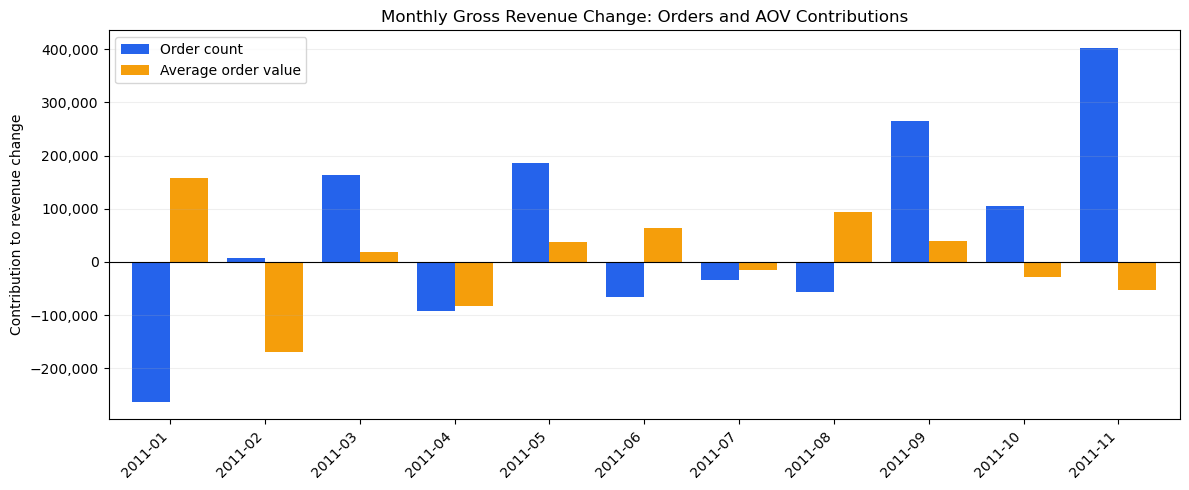

In [4]:
ax = drivers.loc[
    valid, ["OrderCountContribution", "AOVContribution"]
].plot.bar(
    figsize=(12, 5),
    color=["#2563EB", "#F59E0B"],
    width=0.8
)

bar_handles = list(ax.containers)

ax.axhline(0, color="black", linewidth=0.8, label="_nolegend_")
ax.legend(
    handles=bar_handles,
    labels=["Order count", "Average order value"]
)
ax.set_title("Monthly Gross Revenue Change: Orders and AOV Contributions")
ax.set_ylabel("Contribution to revenue change")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,GrossRevenue,UnitsSold,Orders,CancellationValue,CancelledUnits,NetRevenue,NetUnits,NetRevenueShare_pct
Country,,,,,,,,
United Kingdom,"8,724,443.673",4639114,17901,"443,053.310","256,111.000","8,281,390.363","4,383,003.000",84.752
Netherlands,"283,889.340",200258,93,409.800,324.000,"283,479.540","199,934.000",2.901
EIRE,"270,850.860",146896,282,"11,470.840","4,776.000","259,380.020","142,120.000",2.655
Germany,"205,381.150",118032,443,"4,761.490","1,798.000","200,619.660","116,234.000",2.053
France,"184,493.000",111226,382,"2,416.400","1,578.000","182,076.600","109,648.000",1.863
Australia,"138,103.810",83890,56,"1,181.310",555.000,"136,922.500","83,335.000",1.401
Switzerland,"53,065.600",30515,50,582.550,300.000,"52,483.050","30,215.000",0.537
Spain,"55,706.560",27724,88,"3,959.910","1,124.000","51,746.650","26,600.000",0.530
Belgium,"36,927.340",22962,98,264.380,82.000,"36,662.960","22,880.000",0.375


Top 3 countries' share of net revenue: 90.31%


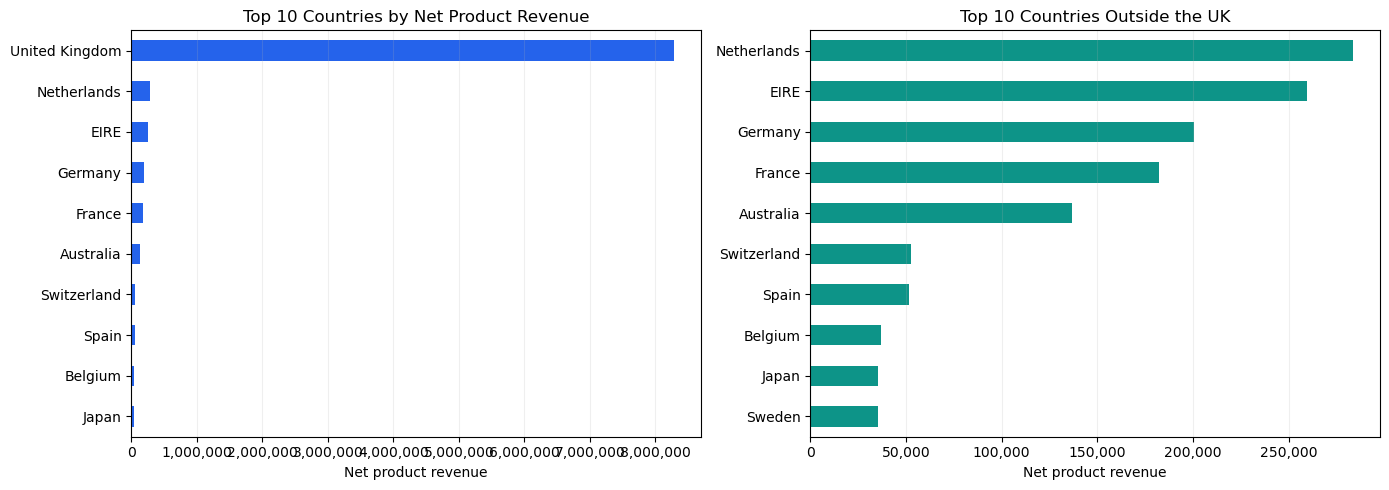

In [5]:
country_summary = (
    sales.groupby("Country")
    .agg(
        GrossRevenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .join(
        cancellations.groupby("Country").agg(
            CancellationValue=("Revenue", lambda x: -x.sum()),
            CancelledUnits=("Quantity", lambda x: -x.sum())
        ),
        how="outer"
    )
    .fillna(0)
)

country_summary["NetRevenue"] = (
    country_summary["GrossRevenue"]
    - country_summary["CancellationValue"]
)
country_summary["NetUnits"] = (
    country_summary["UnitsSold"]
    - country_summary["CancelledUnits"]
)
country_summary["NetRevenueShare_pct"] = (
    country_summary["NetRevenue"]
    / country_summary["NetRevenue"].sum()
    * 100
)

country_summary = country_summary.sort_values(
    "NetRevenue", ascending=False
)

np.testing.assert_allclose(
    country_summary[
        ["GrossRevenue", "CancellationValue", "NetRevenue"]
    ].sum().to_numpy(),
    revenue_check.to_numpy(),
    rtol=0,
    atol=0.000001
)
assert country_summary["Orders"].sum() == sales["InvoiceNo"].nunique()
assert country_summary["NetUnits"].sum() == df.loc[
    df["IsNetProductRevenueEligible"], "Quantity"
].sum()

display(country_summary.head(10))
print(
    "Top 3 countries' share of net revenue: "
    f"{country_summary['NetRevenueShare_pct'].head(3).sum():.2f}%"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_summary.head(10)["NetRevenue"].sort_values().plot.barh(
    ax=axes[0], color="#2563EB"
)
country_summary.drop(
    index="United Kingdom", errors="ignore"
).head(10)["NetRevenue"].sort_values().plot.barh(
    ax=axes[1], color="#0D9488"
)

axes[0].set_title("Top 10 Countries by Net Product Revenue")
axes[1].set_title("Top 10 Countries Outside the UK")

for ax in axes:
    ax.set_xlabel("Net product revenue")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

,NetRevenue,Orders,GrossAOV,KnownCustomers,IdentifiedGrossCoverage_pct,TopCustomerShareOfIdentifiedGross_pct
Country,,,,,,
United Kingdom,"8,281,390.363",17901,487.372,"3,916.000",83.018,3.585
Netherlands,"283,479.540",93,"3,052.574",9.000,100.000,98.326
EIRE,"259,380.020",282,960.464,3.000,94.891,52.979
Germany,"200,619.660",443,463.614,94.000,100.000,8.467
France,"182,076.600",382,482.966,87.000,99.625,10.202
Australia,"136,922.500",56,"2,466.139",9.000,100.000,90.196
Switzerland,"52,483.050",50,"1,061.312",21.000,98.825,21.114
Spain,"51,746.650",88,633.029,30.000,100.000,21.525
Belgium,"36,662.960",98,376.810,25.000,100.000,12.829


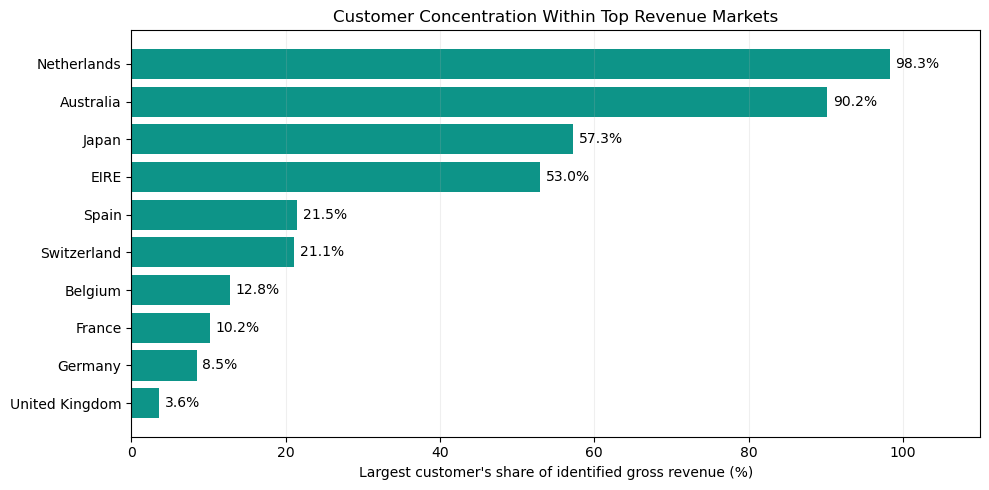

In [6]:
identified_sales = sales.loc[sales["HasCustomerID"]].copy()

customer_country = (
    identified_sales.groupby(["Country", "CustomerID"], as_index=False)
    .agg(GrossRevenue=("Revenue", "sum"))
)

country_customers = (
    customer_country.groupby("Country")
    .agg(
        KnownCustomers=("CustomerID", "nunique"),
        IdentifiedGrossRevenue=("GrossRevenue", "sum"),
        LargestCustomerGross=("GrossRevenue", "max")
    )
)

country_profile = country_summary.join(country_customers)

country_profile["GrossAOV"] = (
    country_profile["GrossRevenue"]
    / country_profile["Orders"].replace(0, np.nan)
)
country_profile["IdentifiedGrossCoverage_pct"] = (
    country_profile["IdentifiedGrossRevenue"]
    / country_profile["GrossRevenue"].replace(0, np.nan)
    * 100
)
country_profile["TopCustomerShareOfIdentifiedGross_pct"] = (
    country_profile["LargestCustomerGross"]
    / country_profile["IdentifiedGrossRevenue"].replace(0, np.nan)
    * 100
)

np.testing.assert_allclose(
    customer_country["GrossRevenue"].sum(),
    identified_sales["Revenue"].sum(),
    rtol=0,
    atol=0.000001
)

top_markets = country_profile.head(10).copy()

display(top_markets[[
    "NetRevenue", "Orders", "GrossAOV", "KnownCustomers",
    "IdentifiedGrossCoverage_pct",
    "TopCustomerShareOfIdentifiedGross_pct"
]])

concentration = top_markets[
    "TopCustomerShareOfIdentifiedGross_pct"
].sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(concentration.index, concentration.values, color="#0D9488")

ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_xlim(0, 110)
ax.set_xlabel("Largest customer's share of identified gross revenue (%)")
ax.set_title("Customer Concentration Within Top Revenue Markets")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

Top 10 products by net revenue


,ProductDisplayName,GrossRevenue,CancellationValue,NetRevenue,NetUnits,OrdersContainingProduct
StockCode,,,,,,
22423,REGENCY CAKESTAND 3 TIER,"174,156.540","9,697.050","164,459.490","12,996.000","1,988.000"
47566,PARTY BUNTING,"99,445.230","1,201.350","98,243.880","18,006.000","1,685.000"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,462.750","6,624.300","97,838.450","35,063.000","2,198.000"
85099B,JUMBO BAG RED RETROSPOT,"94,159.810","1,984.020","92,175.790","47,256.000","2,089.000"
23084,RABBIT NIGHT LIGHT,"66,870.030",208.400,"66,661.630","30,631.000",994.000
22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.590","1,160.350","63,715.240","18,876.000","1,160.000"
84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.620",135.200,"58,792.420","36,282.000","1,455.000"
79321,CHILLI LIGHTS,"54,096.360",349.700,"53,746.660","10,222.000",661.000
22502,PICNIC BASKET WICKER SMALL,"51,408.770",385.250,"51,023.520","1,862.000",463.000


Top 10 products by net units


,ProductDisplayName,GrossRevenue,CancellationValue,NetRevenue,NetUnits,OrdersContainingProduct
StockCode,,,,,,
22197,POPCORN HOLDER,"51,334.470",366.550,"50,967.920","56,427.000","1,392.000"
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"13,814.010",253.920,"13,560.090","53,751.000",535.000
85099B,JUMBO BAG RED RETROSPOT,"94,159.810","1,984.020","92,175.790","47,256.000","2,089.000"
84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.620",135.200,"58,792.420","36,282.000","1,455.000"
21212,PACK OF 72 RETROSPOT CAKE CASES,"21,246.450",199.380,"21,047.070","36,016.000","1,320.000"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,462.750","6,624.300","97,838.450","35,063.000","2,198.000"
23084,RABBIT NIGHT LIGHT,"66,870.030",208.400,"66,661.630","30,631.000",994.000
22492,MINI PAINT SET VINTAGE,"16,937.820",127.400,"16,810.420","26,437.000",380.000
22616,PACK OF 12 LONDON TISSUES,"7,975.980",8.160,"7,967.820","26,095.000",512.000


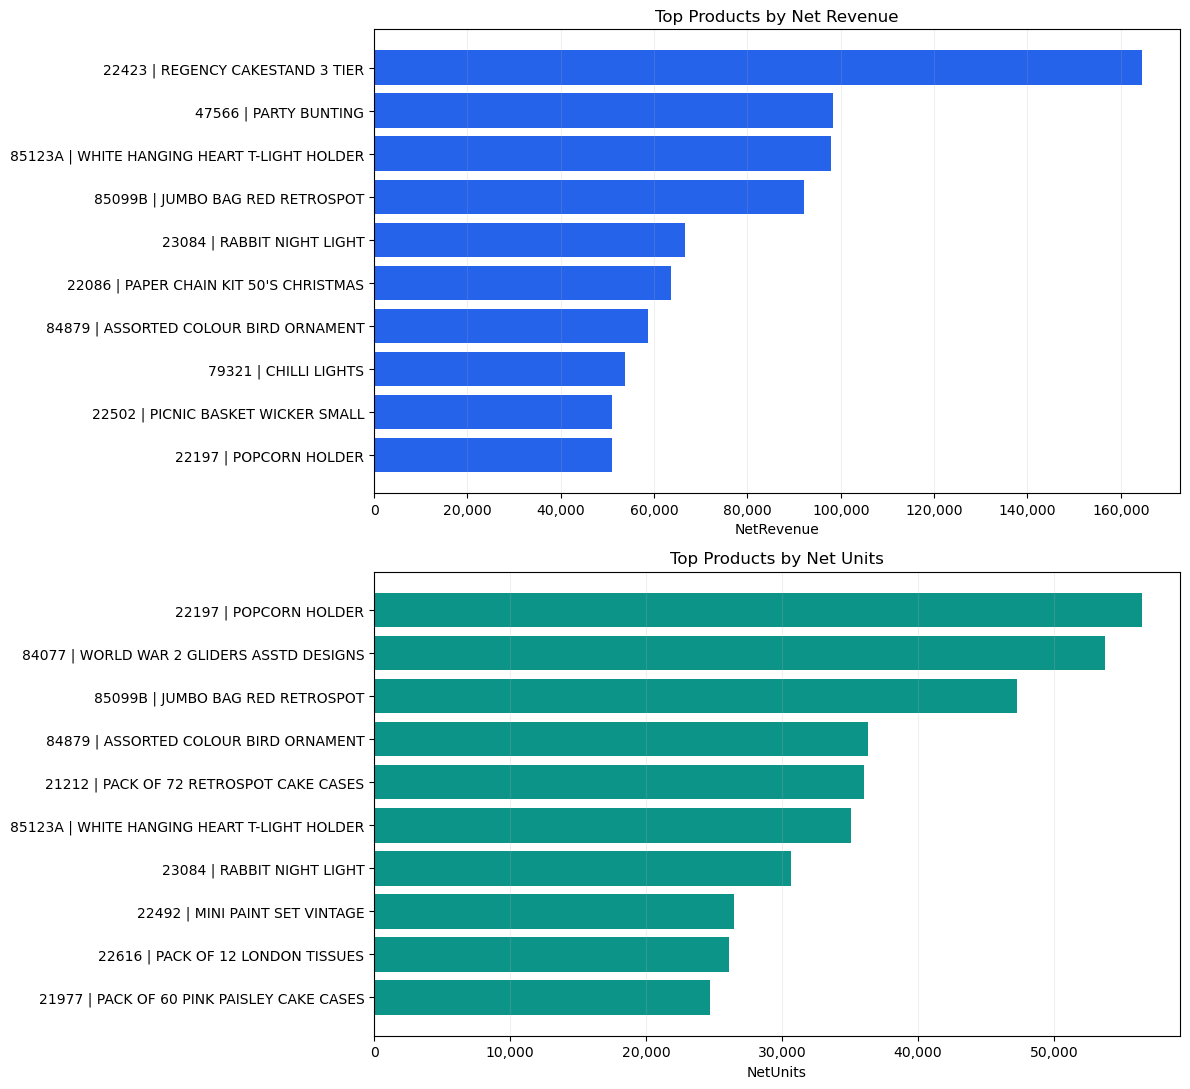

In [7]:
product_summary = (
    sales.groupby("StockCode")
    .agg(
        GrossRevenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        OrdersContainingProduct=("InvoiceNo", "nunique")
    )
    .join(
        cancellations.groupby("StockCode").agg(
            CancellationValue=("Revenue", lambda x: -x.sum()),
            CancelledUnits=("Quantity", lambda x: -x.sum())
        ),
        how="outer"
    )
    .fillna(0)
)

product_names = (
    df.loc[
        df["IsNetProductRevenueEligible"],
        ["StockCode", "ProductDisplayName"]
    ]
    .drop_duplicates()
)

assert product_names["StockCode"].is_unique

product_summary = product_summary.join(
    product_names.set_index("StockCode")
)

product_summary["NetRevenue"] = (
    product_summary["GrossRevenue"]
    - product_summary["CancellationValue"]
)
product_summary["NetUnits"] = (
    product_summary["UnitsSold"]
    - product_summary["CancelledUnits"]
)

product_summary = product_summary.sort_values(
    "NetRevenue", ascending=False
)

np.testing.assert_allclose(
    product_summary[
        ["GrossRevenue", "CancellationValue", "NetRevenue"]
    ].sum().to_numpy(),
    revenue_check.to_numpy(),
    rtol=0,
    atol=0.000001
)
assert product_summary["NetUnits"].sum() == df.loc[
    df["IsNetProductRevenueEligible"], "Quantity"
].sum()
assert product_summary["ProductDisplayName"].notna().all()

columns_to_show = [
    "ProductDisplayName", "GrossRevenue", "CancellationValue",
    "NetRevenue", "NetUnits", "OrdersContainingProduct"
]

print("Top 10 products by net revenue")
display(product_summary.head(10)[columns_to_show])

print("Top 10 products by net units")
display(product_summary.nlargest(10, "NetUnits")[columns_to_show])

fig, axes = plt.subplots(2, 1, figsize=(12, 11))

for ax, metric, title, color in [
    (axes[0], "NetRevenue", "Top Products by Net Revenue", "#2563EB"),
    (axes[1], "NetUnits", "Top Products by Net Units", "#0D9488")
]:
    top = product_summary.nlargest(10, metric).sort_values(metric)
    labels = [
        f"{code} | {name}"
        for code, name in zip(top.index, top["ProductDisplayName"])
    ]
    ax.barh(labels, top[metric], color=color)
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

,value
Products with positive net revenue,"3,899.000"
Products needed for 80%,840.000
Share of positive-net products needed (%),21.544
Revenue share of top 20% of products (%),78.277
Products with zero net revenue,4.000
Products with negative net revenue,19.000
Combined negative net revenue,-314.540


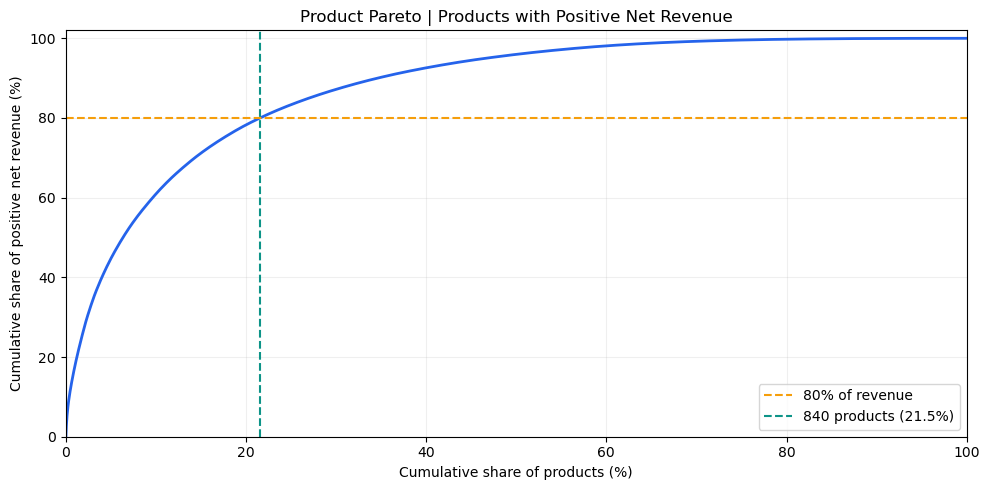

In [8]:
pareto = (
    product_summary.loc[product_summary["NetRevenue"].gt(0)]
    .copy()
    .sort_index()
    .sort_values("NetRevenue", ascending=False, kind="stable")
)

nonpositive = product_summary.loc[
    product_summary["NetRevenue"].le(0)
].copy()

assert len(pareto) + len(nonpositive) == len(product_summary)
assert not pareto.empty

positive_net_total = pareto["NetRevenue"].sum()

pareto["ProductRank"] = np.arange(1, len(pareto) + 1)
pareto["CumulativeProduct_pct"] = (
    pareto["ProductRank"] / len(pareto) * 100
)
pareto["CumulativeRevenue_pct"] = (
    pareto["NetRevenue"].cumsum() / positive_net_total * 100
)

n80 = int(
    np.searchsorted(
        pareto["CumulativeRevenue_pct"].to_numpy(), 80
    ) + 1
)
top20_count = int(np.ceil(len(pareto) * 0.20))

np.testing.assert_allclose(
    positive_net_total + nonpositive["NetRevenue"].sum(),
    product_summary["NetRevenue"].sum(),
    rtol=0,
    atol=0.000001
)
assert pareto["CumulativeRevenue_pct"].is_monotonic_increasing
assert np.isclose(pareto["CumulativeRevenue_pct"].iloc[-1], 100)

pareto_metrics = pd.Series({
    "Products with positive net revenue": len(pareto),
    "Products needed for 80%": n80,
    "Share of positive-net products needed (%)": n80 / len(pareto) * 100,
    "Revenue share of top 20% of products (%)":
        pareto["CumulativeRevenue_pct"].iloc[top20_count - 1],
    "Products with zero net revenue":
        product_summary["NetRevenue"].eq(0).sum(),
    "Products with negative net revenue":
        product_summary["NetRevenue"].lt(0).sum(),
    "Combined negative net revenue": nonpositive["NetRevenue"].sum()
})

display(pareto_metrics.to_frame("value"))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    np.r_[0, pareto["CumulativeProduct_pct"].to_numpy()],
    np.r_[0, pareto["CumulativeRevenue_pct"].to_numpy()],
    color="#2563EB",
    linewidth=2
)
ax.axhline(80, color="#F59E0B", linestyle="--", label="80% of revenue")
ax.axvline(
    n80 / len(pareto) * 100,
    color="#0D9488",
    linestyle="--",
    label=f"{n80:,} products ({n80 / len(pareto):.1%})"
)

ax.set(
    title="Product Pareto | Products with Positive Net Revenue",
    xlabel="Cumulative share of products (%)",
    ylabel="Cumulative share of positive net revenue (%)",
    xlim=(0, 100),
    ylim=(0, 102)
)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
customer_purchases = df.loc[df["IsCustomerPurchaseEligible"]].copy()
customer_cancellations = df.loc[
    df["IsProductCancellation"] & df["HasCustomerID"]
].copy()

snapshot_date = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

customer_metrics = (
    customer_purchases.groupby("CustomerID")
    .agg(
        FirstPurchase=("InvoiceTimestamp", "min"),
        LastPurchase=("InvoiceTimestamp", "max"),
        Frequency=("InvoiceNo", "nunique"),
        MonetaryGross=("Revenue", "sum")
    )
)

cancellation_metrics = (
    customer_cancellations.groupby("CustomerID")
    .agg(
        CancellationValue=("Revenue", lambda x: -x.sum()),
        CancellationInvoices=("InvoiceNo", "nunique")
    )
)

customer_metrics = customer_metrics.join(cancellation_metrics)
customer_metrics[["CancellationValue", "CancellationInvoices"]] = (
    customer_metrics[["CancellationValue", "CancellationInvoices"]]
    .fillna(0)
)

customer_metrics["Recency"] = (
    snapshot_date - customer_metrics["LastPurchase"].dt.normalize()
).dt.days

customer_metrics["MonetaryNet"] = (
    customer_metrics["MonetaryGross"]
    - customer_metrics["CancellationValue"]
)

cancellation_only = cancellation_metrics.loc[
    ~cancellation_metrics.index.isin(customer_metrics.index)
].copy()

assert customer_metrics.index.is_unique
assert customer_metrics["Recency"].ge(1).all()
assert customer_metrics["Frequency"].ge(1).all()
assert customer_metrics["Frequency"].sum() == (
    customer_purchases["InvoiceNo"].nunique()
)

np.testing.assert_allclose(
    customer_metrics["MonetaryGross"].sum(),
    customer_purchases["Revenue"].sum(),
    rtol=0,
    atol=0.000001
)
np.testing.assert_allclose(
    customer_metrics["CancellationValue"].sum()
    + cancellation_only["CancellationValue"].sum(),
    -customer_cancellations["Revenue"].sum(),
    rtol=0,
    atol=0.000001
)

print(f"Snapshot date: {snapshot_date.date()}")
print(f"Customers with purchases: {len(customer_metrics):,}")
print(f"Customers with cancellations only: {len(cancellation_only):,}")
print(
    "Purchasing customers with net revenue <= 0:",
    customer_metrics["MonetaryNet"].le(0).sum()
)

display(
    customer_metrics[
        ["Recency", "Frequency", "MonetaryGross",
         "CancellationValue", "MonetaryNet"]
    ].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
)

display(
    customer_metrics.nlargest(10, "CancellationValue")[
        ["Recency", "Frequency", "MonetaryGross",
         "CancellationValue", "MonetaryNet"]
    ]
)

Snapshot date: 2011-12-10
Customers with purchases: 4,334
Customers with cancellations only: 28
Purchasing customers with net revenue <= 0: 12


,Recency,Frequency,MonetaryGross,CancellationValue,MonetaryNet
count,"4,334.000","4,334.000","4,334.000","4,334.000","4,334.000"
mean,93.227,4.246,"2,015.973",107.944,"1,908.030"
std,100.175,7.635,"8,903.674","2,855.387","8,291.084"
min,1.000,1.000,3.750,0.000,-141.480
25%,18.000,1.000,304.240,0.000,296.782
50%,51.000,2.000,662.565,0.000,646.840
75%,143.000,5.000,"1,631.622",14.780,"1,600.840"
95%,312.000,13.000,"5,735.215",147.149,"5,638.439"
99%,369.000,30.000,"18,715.313",710.001,"17,049.103"
max,374.000,206.000,"279,138.020","168,469.600","278,778.020"


,Recency,Frequency,MonetaryGross,CancellationValue,MonetaryNet
CustomerID,,,,,
16446,1,2,"168,472.500","168,469.600",2.900
12346,326,1,"77,183.600","77,183.600",0.000
15749,236,3,"44,534.300","22,998.400","21,535.900"
16029,39,62,"72,708.090","12,338.160","60,369.930"
12931,22,15,"42,055.960","8,511.150","33,544.810"
14911,2,198,"136,161.830","7,393.590","128,768.240"
14607,16,12,"15,021.500","5,228.400","9,793.100"
17450,9,46,"194,390.790","4,815.260","189,575.530"
17949,2,44,"58,030.480","4,814.740","53,215.740"


In [10]:
rfm = customer_metrics.loc[
    customer_metrics["MonetaryNet"].gt(0)
].copy()

customer_value_review = customer_metrics.loc[
    customer_metrics["MonetaryNet"].le(0)
].copy()

assert len(rfm) + len(customer_value_review) == len(customer_metrics)

rfm_thresholds = rfm[
    ["Recency", "Frequency", "MonetaryNet"]
].quantile([0.25, 0.50, 0.75])

for metric, score_column in [
    ("Recency", "RScore"),
    ("Frequency", "FScore"),
    ("MonetaryNet", "MScore")
]:
    thresholds = rfm_thresholds[metric].to_numpy()
    scores = (
        np.searchsorted(
            thresholds,
            rfm[metric].to_numpy(),
            side="left"
        ) + 1
    )
    rfm[score_column] = 5 - scores if metric == "Recency" else scores

    assert rfm[score_column].between(1, 4).all()
    assert rfm.groupby(metric)[score_column].nunique().le(1).all()

rfm["RFMCode"] = (
    rfm["RScore"].astype("string")
    + rfm["FScore"].astype("string")
    + rfm["MScore"].astype("string")
)

pd.testing.assert_frame_equal(
    rfm[customer_metrics.columns],
    customer_metrics.loc[rfm.index]
)

score_counts = pd.DataFrame({
    column: rfm[column].value_counts().reindex(range(1, 5), fill_value=0)
    for column in ["RScore", "FScore", "MScore"]
})
score_counts.index.name = "Score"

assert score_counts.sum().eq(len(rfm)).all()

print(f"Customers scored: {len(rfm):,}")
print(f"Customers separated for value review: {len(customer_value_review):,}")

print("\nQuartile thresholds")
display(rfm_thresholds)

print("\nCustomers per score")
display(score_counts)

print("\nSample RFM scores")
display(
    rfm[[
        "Recency", "Frequency", "MonetaryNet",
        "RScore", "FScore", "MScore", "RFMCode"
    ]].head(10)
)

Customers scored: 4,322
Customers separated for value review: 12

Quartile thresholds


,Recency,Frequency,MonetaryNet
0.250,18.000,1.000,298.955
0.500,51.000,2.000,649.555
0.750,143.000,5.000,"1,609.378"



Customers per score


,RScore,FScore,MScore
Score,,,
1,1078,1495,1081
2,1076,829,1080
3,1067,1133,1080
4,1101,865,1081



Sample RFM scores


,Recency,Frequency,MonetaryNet,RScore,FScore,MScore,RFMCode
CustomerID,,,,,,,
12347,3,7,"4,310.000",4,4,4,444
12348,76,4,"1,437.240",2,3,3,233
12349,19,1,"1,457.550",3,1,3,313
12350,311,1,294.400,1,1,1,111
12352,37,7,"1,265.410",3,4,3,343
12353,205,1,89.000,1,1,1,111
12354,233,1,"1,079.400",1,1,3,113
12355,215,1,459.400,1,1,2,112
12356,23,3,"2,487.430",3,3,4,334


,Customers,NetRevenue,MedianRecency,MedianFrequency,MedianCustomerNet,CustomerShare_pct,NetRevenueShare_pct
Segment,,,,,,,
Champions,1289,"6,193,483.821",15.000,6.000,"2,131.900",29.824,74.894
At Risk,846,"1,281,062.041",96.000,3.000,"1,035.560",19.574,15.491
Dormant Lower-value,1308,"366,074.891",190.000,1.000,259.850,30.264,4.427
Potential Loyalists,366,"233,402.320",20.000,2.000,507.810,8.468,2.822
Recent One-time,363,"123,203.690",26.000,1.000,245.750,8.399,1.490
Frequent Lower-value,150,"72,410.560",22.500,3.000,517.585,3.471,0.876


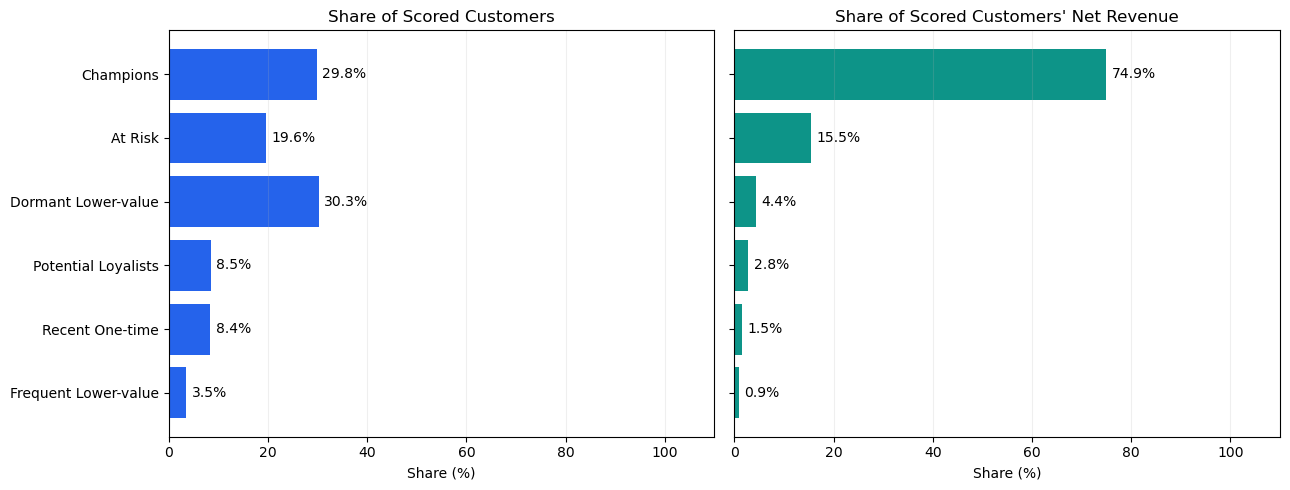

In [11]:
rfm_segmented = rfm.copy()

r = rfm_segmented["RScore"]
f = rfm_segmented["FScore"]
m = rfm_segmented["MScore"]

rfm_segmented["Segment"] = np.select(
    [
        r.ge(3) & f.ge(3) & m.ge(3),
        r.ge(3) & f.ge(3) & m.le(2),
        r.ge(3) & f.eq(2),
        r.ge(3) & f.eq(1),
        r.le(2) & (f.ge(3) | m.ge(3)),
        r.le(2) & f.le(2) & m.le(2)
    ],
    [
        "Champions",
        "Frequent Lower-value",
        "Potential Loyalists",
        "Recent One-time",
        "At Risk",
        "Dormant Lower-value"
    ],
    default="Unassigned"
)

assert len(rfm_segmented) == len(rfm)
assert rfm_segmented["Segment"].ne("Unassigned").all()
pd.testing.assert_frame_equal(rfm_segmented[rfm.columns], rfm)

segment_summary = (
    rfm_segmented.groupby("Segment")
    .agg(
        Customers=("MonetaryNet", "size"),
        NetRevenue=("MonetaryNet", "sum"),
        MedianRecency=("Recency", "median"),
        MedianFrequency=("Frequency", "median"),
        MedianCustomerNet=("MonetaryNet", "median")
    )
    .sort_values("NetRevenue", ascending=False)
)

segment_summary["CustomerShare_pct"] = (
    segment_summary["Customers"] / len(rfm_segmented) * 100
)
segment_summary["NetRevenueShare_pct"] = (
    segment_summary["NetRevenue"]
    / rfm_segmented["MonetaryNet"].sum()
    * 100
)

assert segment_summary["Customers"].sum() == len(rfm_segmented)
np.testing.assert_allclose(
    segment_summary["NetRevenue"].sum(),
    rfm["MonetaryNet"].sum(),
    rtol=0,
    atol=0.000001
)

display(segment_summary)

plot_data = segment_summary.iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, metric, title, color in [
    (axes[0], "CustomerShare_pct", "Share of Scored Customers", "#2563EB"),
    (axes[1], "NetRevenueShare_pct", "Share of Scored Customers' Net Revenue", "#0D9488")
]:
    bars = ax.barh(plot_data.index, plot_data[metric], color=color)
    ax.bar_label(bars, fmt="%.1f%%", padding=4)
    ax.set_xlim(0, 110)
    ax.set_xlabel("Share (%)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

,Customers,PurchaseInvoices,GrossRevenue,CancellationValue,NetRevenue,CustomerShare_pct,NetRevenueShare_pct
PurchaseGroup,,,,,,,
One-time,1505,1505,"626,605.901","90,330.920","536,274.981",34.725,6.485
Repeat,2829,16897,"8,110,621.742","377,496.810","7,733,124.932",65.275,93.515


Observed repeat purchase rate: 65.27%


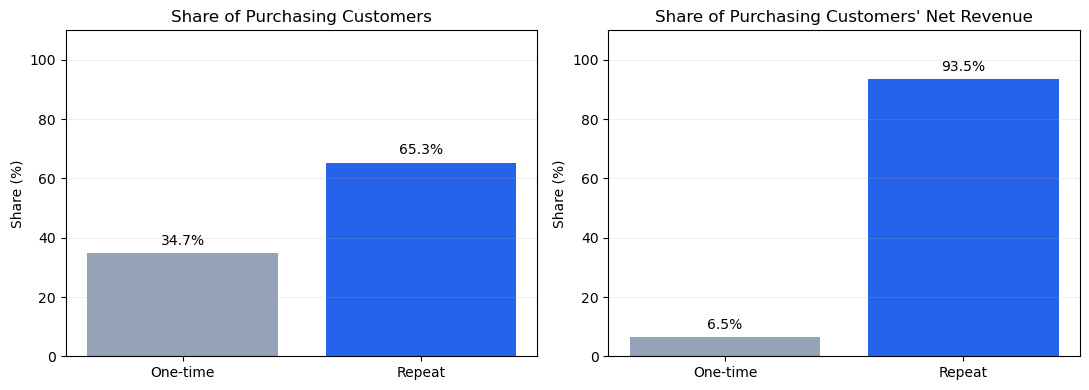

In [12]:
repeat_customers = customer_metrics.copy()

repeat_customers["PurchaseGroup"] = np.where(
    repeat_customers["Frequency"].ge(2),
    "Repeat",
    "One-time"
)

repeat_summary = (
    repeat_customers.groupby("PurchaseGroup")
    .agg(
        Customers=("Frequency", "size"),
        PurchaseInvoices=("Frequency", "sum"),
        GrossRevenue=("MonetaryGross", "sum"),
        CancellationValue=("CancellationValue", "sum"),
        NetRevenue=("MonetaryNet", "sum")
    )
    .reindex(["One-time", "Repeat"])
)

repeat_summary["CustomerShare_pct"] = (
    repeat_summary["Customers"] / len(repeat_customers) * 100
)
repeat_summary["NetRevenueShare_pct"] = (
    repeat_summary["NetRevenue"]
    / repeat_customers["MonetaryNet"].sum()
    * 100
)

assert repeat_summary["Customers"].sum() == len(customer_metrics)
assert repeat_summary["PurchaseInvoices"].sum() == (
    customer_purchases["InvoiceNo"].nunique()
)

np.testing.assert_allclose(
    repeat_summary["NetRevenue"].sum(),
    customer_metrics["MonetaryNet"].sum(),
    rtol=0,
    atol=0.000001
)

display(repeat_summary)
print(
    "Observed repeat purchase rate: "
    f"{repeat_summary.loc['Repeat', 'CustomerShare_pct']:.2f}%"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric, title in [
    (axes[0], "CustomerShare_pct", "Share of Purchasing Customers"),
    (axes[1], "NetRevenueShare_pct", "Share of Purchasing Customers' Net Revenue")
]:
    bars = ax.bar(
        repeat_summary.index,
        repeat_summary[metric],
        color=["#94A3B8", "#2563EB"]
    )
    ax.bar_label(bars, fmt="%.1f%%", padding=4)
    ax.set_ylim(0, 110)
    ax.set_ylabel("Share (%)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

,CohortSize,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11
CohortMonth,,,,,,,,,,,,,
2010-12,884,100.000,36.500,32.400,38.300,36.200,39.800,36.200,34.800,35.300,39.500,37.300,50.200
2011-01,416,100.000,21.900,26.700,22.800,31.700,28.800,24.800,24.000,29.600,32.700,36.500,NaN
2011-02,380,100.000,18.700,18.700,28.700,27.100,24.500,25.500,27.400,24.700,30.500,NaN,NaN
2011-03,452,100.000,14.800,25.200,19.900,22.300,16.800,26.800,23.000,27.900,NaN,NaN,NaN
2011-04,300,100.000,21.000,20.300,21.000,19.700,22.700,21.700,26.000,NaN,NaN,NaN,NaN
2011-05,284,100.000,19.000,17.300,17.300,20.800,23.200,26.400,NaN,NaN,NaN,NaN,NaN
2011-06,242,100.000,17.400,15.700,26.400,23.100,33.100,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,187,100.000,17.600,20.300,22.500,27.300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169,100.000,20.100,24.300,24.300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


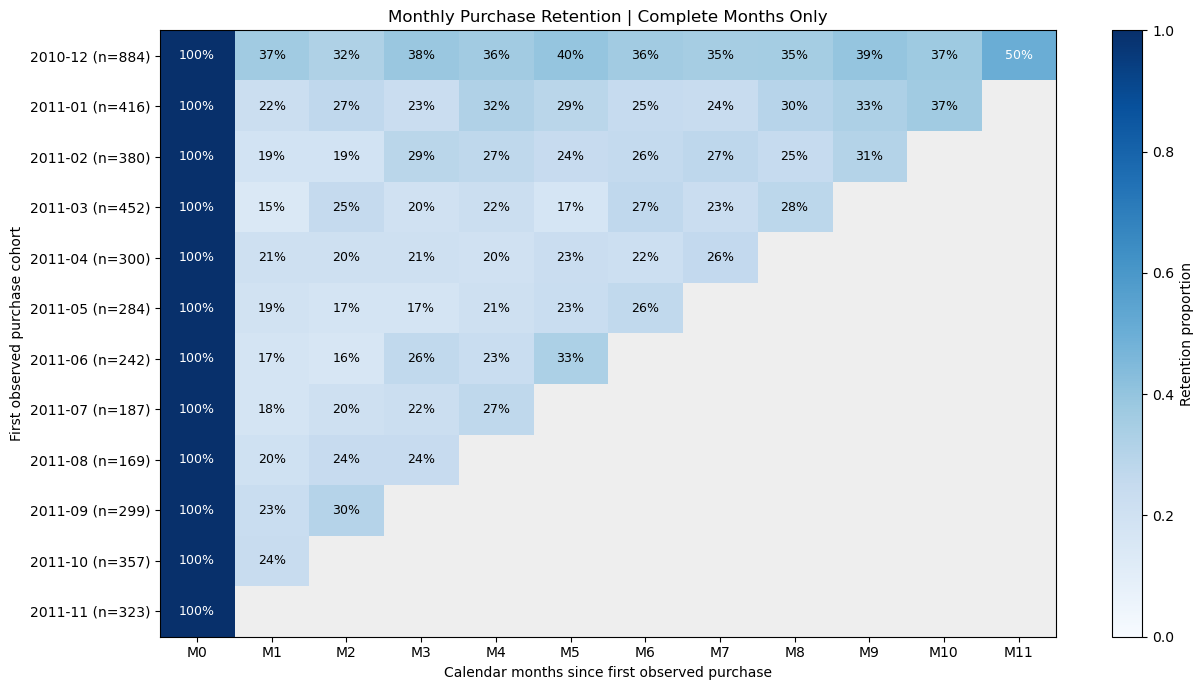

In [13]:
full_months = monthly.index[~monthly["IsPartialMonth"]]

cohort_activity = customer_purchases.loc[
    customer_purchases["YearMonth"].isin(full_months),
    ["CustomerID", "InvoiceTimestamp"]
].copy()

cohort_activity["PurchaseMonth"] = (
    cohort_activity["InvoiceTimestamp"].dt.to_period("M")
)
cohort_activity = cohort_activity[
    ["CustomerID", "PurchaseMonth"]
].drop_duplicates()

cohort_activity["CohortMonth"] = (
    cohort_activity.groupby("CustomerID")["PurchaseMonth"]
    .transform("min")
)

cohort_activity["MonthIndex"] = (
    cohort_activity["PurchaseMonth"].astype("int64")
    - cohort_activity["CohortMonth"].astype("int64")
)

cohort_sizes = (
    cohort_activity.groupby("CohortMonth")["CustomerID"].nunique()
)

last_full_month = pd.Period(full_months.max(), freq="M")
max_age = last_full_month.ordinal - cohort_sizes.index.min().ordinal

cohort_counts = (
    cohort_activity.groupby(["CohortMonth", "MonthIndex"])["CustomerID"]
    .nunique()
    .unstack("MonthIndex")
    .reindex(index=cohort_sizes.index, columns=range(max_age + 1))
    .fillna(0)
    .astype(float)
)

for cohort_month in cohort_counts.index:
    available_age = last_full_month.ordinal - cohort_month.ordinal
    cohort_counts.loc[
        cohort_month, cohort_counts.columns > available_age
    ] = np.nan

cohort_retention = cohort_counts.div(cohort_sizes, axis=0)

assert cohort_sizes.sum() == cohort_activity["CustomerID"].nunique()
assert cohort_counts[0].eq(cohort_sizes).all()
assert cohort_retention[0].eq(1).all()
assert cohort_retention.stack().between(0, 1).all()

display(
    cohort_sizes.rename("CohortSize").to_frame()
    .join(cohort_retention.mul(100).add_prefix("M"))
    .round(1)
)

fig, ax = plt.subplots(figsize=(13, 7))
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#EEEEEE")

values = cohort_retention.to_numpy()
heatmap = ax.imshow(
    np.ma.masked_invalid(values),
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=1
)

for row, column in np.argwhere(~np.isnan(values)):
    value = values[row, column]
    ax.text(
        column, row, f"{value:.0%}",
        ha="center", va="center",
        color="white" if value >= 0.5 else "black",
        fontsize=9
    )

ax.set_xticks(range(len(cohort_retention.columns)))
ax.set_xticklabels([f"M{i}" for i in cohort_retention.columns])
ax.set_yticks(range(len(cohort_retention)))
ax.set_yticklabels([
    f"{month} (n={cohort_sizes.loc[month]:,})"
    for month in cohort_retention.index
])
ax.set_title("Monthly Purchase Retention | Complete Months Only")
ax.set_xlabel("Calendar months since first observed purchase")
ax.set_ylabel("First observed purchase cohort")
fig.colorbar(heatmap, ax=ax, label="Retention proportion")
plt.tight_layout()
plt.show()

,CohortSize,ReturningCustomers_M1,M1Retention_pct
CohortMonth,,,
2010-12,884,323,36.540
2011-01,416,91,21.880
2011-02,380,71,18.680
2011-03,452,67,14.820
2011-04,300,63,21.000
2011-05,284,54,19.010
2011-06,242,42,17.360
2011-07,187,33,17.650
2011-08,169,34,20.120


Baseline cohorts: 2011-01 to 2011-10
Baseline customers: 3,086
Weighted M1 retention: 19.73%


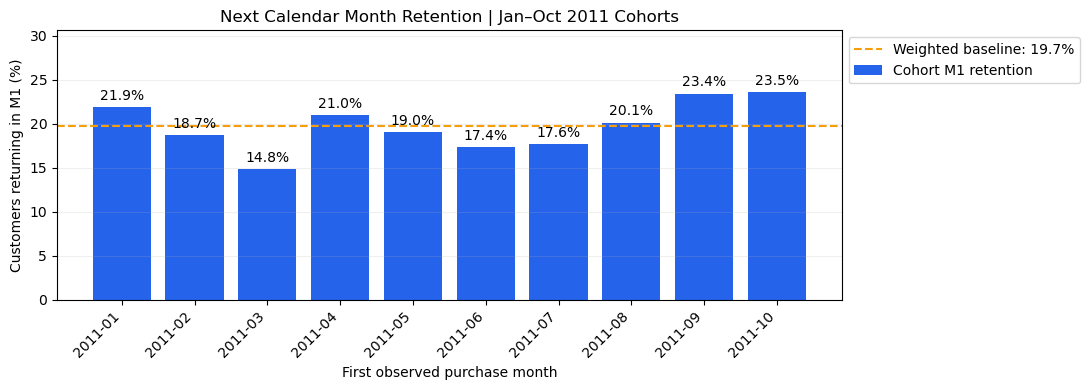

In [14]:
m1_summary = pd.DataFrame({
    "CohortSize": cohort_sizes,
    "ReturningCustomers_M1": cohort_counts[1]
})

m1_summary = m1_summary.loc[
    m1_summary["ReturningCustomers_M1"].notna()
].copy()

m1_summary["ReturningCustomers_M1"] = (
    m1_summary["ReturningCustomers_M1"].astype("int64")
)
m1_summary["M1Retention_pct"] = (
    m1_summary["ReturningCustomers_M1"]
    / m1_summary["CohortSize"]
    * 100
)

first_observed_month = df["InvoiceDate"].min().to_period("M")

m1_baseline = m1_summary.loc[
    m1_summary.index > first_observed_month
].copy()

weighted_m1 = (
    m1_baseline["ReturningCustomers_M1"].sum()
    / m1_baseline["CohortSize"].sum()
    * 100
)

assert not m1_baseline.empty
assert m1_summary["ReturningCustomers_M1"].between(
    0, m1_summary["CohortSize"]
).all()
assert m1_baseline.index.max() + 1 <= last_full_month

np.testing.assert_allclose(
    weighted_m1,
    np.average(
        m1_baseline["M1Retention_pct"],
        weights=m1_baseline["CohortSize"]
    ),
    rtol=0,
    atol=0.000001
)

display(m1_summary.round(2))

print(
    f"Baseline cohorts: {m1_baseline.index.min()} "
    f"to {m1_baseline.index.max()}"
)
print(f"Baseline customers: {m1_baseline['CohortSize'].sum():,}")
print(f"Weighted M1 retention: {weighted_m1:.2f}%")

fig, ax = plt.subplots(figsize=(11, 4))

bars = ax.bar(
    m1_baseline.index.astype(str),
    m1_baseline["M1Retention_pct"],
    color="#2563EB",
    label="Cohort M1 retention"
)
ax.bar_label(bars, fmt="%.1f%%", padding=3)

ax.axhline(
    weighted_m1,
    color="#F59E0B",
    linestyle="--",
    label=f"Weighted baseline: {weighted_m1:.1f}%"
)

ax.set_ylim(0, max(m1_baseline["M1Retention_pct"].max() * 1.3, 30))
ax.set_title("Next Calendar Month Retention | Jan–Oct 2011 Cohorts")
ax.set_ylabel("Customers returning in M1 (%)")
ax.set_xlabel("First observed purchase month")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(axis="y", alpha=0.2)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,GrossRevenue,CancellationValue,IsPartialMonth,SaleInvoices,CancellationInvoices,CancellationValueToGross_pct,CancellationDocumentShare_pct
YearMonth,,,,,,,
2010-12,"775,638.360","17,547.860",False,1550,301,2.262,16.261
2011-01,"670,380.240","91,525.050",False,1081,247,13.653,18.599
2011-02,"507,799.870","8,335.520",False,1093,191,1.641,14.875
2011-03,"689,833.510","10,504.300",False,1440,281,1.523,16.328
2011-04,"515,377.991","33,316.060",False,1235,220,6.464,15.120
2011-05,"739,953.000","8,948.230",False,1668,267,1.209,13.798
2011-06,"737,558.980","13,713.840",False,1525,299,1.859,16.393
2011-07,"688,219.341","11,407.260",False,1452,236,1.658,13.981
2011-08,"724,216.500","22,926.570",False,1339,240,3.166,15.199


Overall cancellation value / gross: 4.64%
Overall cancellation document share: 14.75%


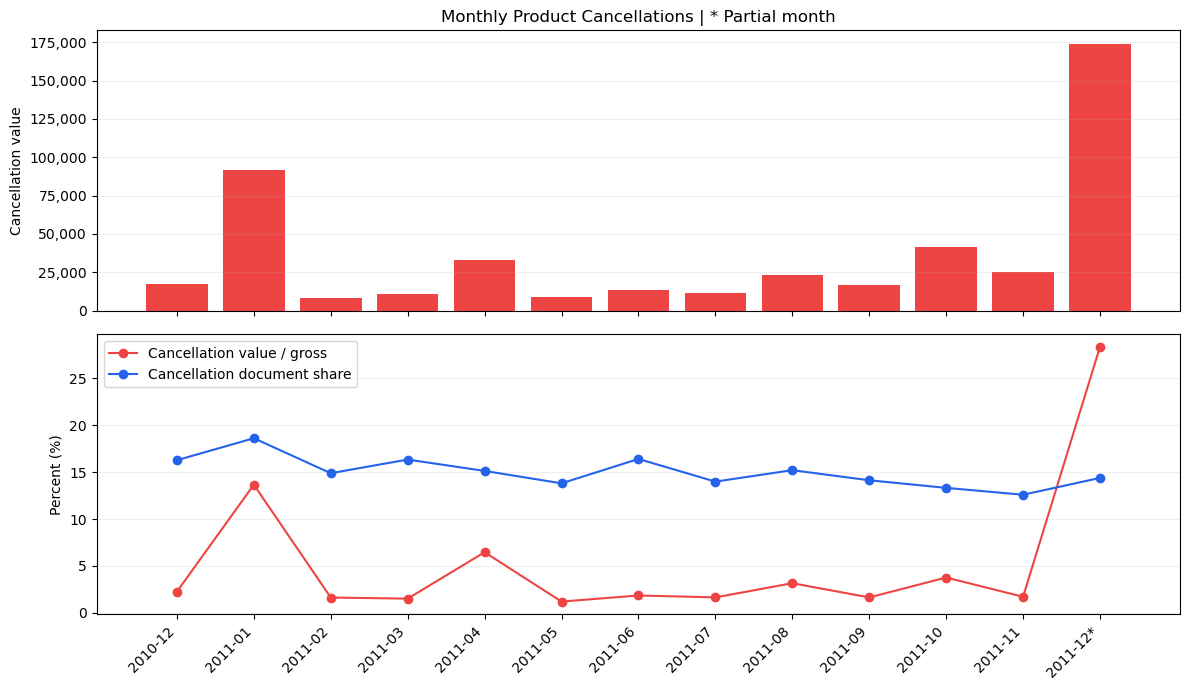

In [15]:
cancellation_monthly = monthly[
    ["GrossRevenue", "CancellationValue", "IsPartialMonth"]
].copy()

cancellation_monthly["SaleInvoices"] = (
    sales.groupby("YearMonth")["InvoiceNo"]
    .nunique()
    .reindex(cancellation_monthly.index, fill_value=0)
)

cancellation_monthly["CancellationInvoices"] = (
    cancellations.groupby("YearMonth")["InvoiceNo"]
    .nunique()
    .reindex(cancellation_monthly.index, fill_value=0)
)

cancellation_monthly["CancellationValueToGross_pct"] = (
    cancellation_monthly["CancellationValue"]
    / cancellation_monthly["GrossRevenue"].replace(0, np.nan)
    * 100
)

cancellation_monthly["CancellationDocumentShare_pct"] = (
    cancellation_monthly["CancellationInvoices"]
    / (
        cancellation_monthly["SaleInvoices"]
        + cancellation_monthly["CancellationInvoices"]
    ).replace(0, np.nan)
    * 100
)

assert set(sales["InvoiceNo"]).isdisjoint(cancellations["InvoiceNo"])
assert cancellation_monthly["CancellationInvoices"].sum() == (
    cancellations["InvoiceNo"].nunique()
)

np.testing.assert_allclose(
    cancellation_monthly["CancellationValue"].sum(),
    -cancellations["Revenue"].sum(),
    rtol=0,
    atol=0.000001
)

overall_value_ratio = (
    cancellation_monthly["CancellationValue"].sum()
    / cancellation_monthly["GrossRevenue"].sum()
    * 100
)

overall_document_share = (
    cancellations["InvoiceNo"].nunique()
    / (
        sales["InvoiceNo"].nunique()
        + cancellations["InvoiceNo"].nunique()
    )
    * 100
)

display(cancellation_monthly)
print(f"Overall cancellation value / gross: {overall_value_ratio:.2f}%")
print(f"Overall cancellation document share: {overall_document_share:.2f}%")

labels = [
    f"{month}*" if partial else month
    for month, partial in zip(
        cancellation_monthly.index,
        cancellation_monthly["IsPartialMonth"]
    )
]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
x = np.arange(len(cancellation_monthly))

axes[0].bar(
    x, cancellation_monthly["CancellationValue"], color="#EF4444"
)
axes[0].set_ylabel("Cancellation value")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

axes[1].plot(
    x,
    cancellation_monthly["CancellationValueToGross_pct"],
    marker="o",
    color="#EF4444",
    label="Cancellation value / gross"
)
axes[1].plot(
    x,
    cancellation_monthly["CancellationDocumentShare_pct"],
    marker="o",
    color="#2563EB",
    label="Cancellation document share"
)
axes[1].set_ylabel("Percent (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].legend()

for ax in axes:
    ax.grid(axis="y", alpha=0.2)

axes[0].set_title("Monthly Product Cancellations | * Partial month")
plt.tight_layout()
plt.show()

,InvoiceTimestamp,CustomerID,Country,ProductLines,Products,CancelledUnits,CancellationValue,ValueShare_pct,CumulativeValueShare_pct
InvoiceNo,,,,,,,,,
C581484,2011-12-09 09:27:00,16446,United Kingdom,1,1,80995,"168,469.600",35.400,35.400
C541433,2011-01-18 10:17:00,12346,United Kingdom,1,1,74215,"77,183.600",16.218,51.619
C550456,2011-04-18 13:08:00,15749,United Kingdom,5,5,9014,"22,998.400",4.833,56.451
C570556,2011-10-11 11:10:00,16029,United Kingdom,9,8,4896,"9,466.560",1.989,58.440
C562375,2011-08-04 14:46:00,14911,EIRE,31,31,2270,"4,345.100",0.913,59.353
C565044,2011-08-31 17:02:00,12931,United Kingdom,7,7,1161,"3,969.930",0.834,60.188
C567527,2011-09-21 09:16:00,17450,United Kingdom,1,1,756,"3,825.360",0.804,60.991
C571499,2011-10-17 15:07:00,12454,Spain,15,15,1006,"3,528.340",0.741,61.733
C564940,2011-08-31 13:10:00,12931,United Kingdom,9,9,2518,"3,491.020",0.734,62.466


Top 2 cancellation invoices' value share: 51.62%
Top 10 cancellation invoices' value share: 63.09%


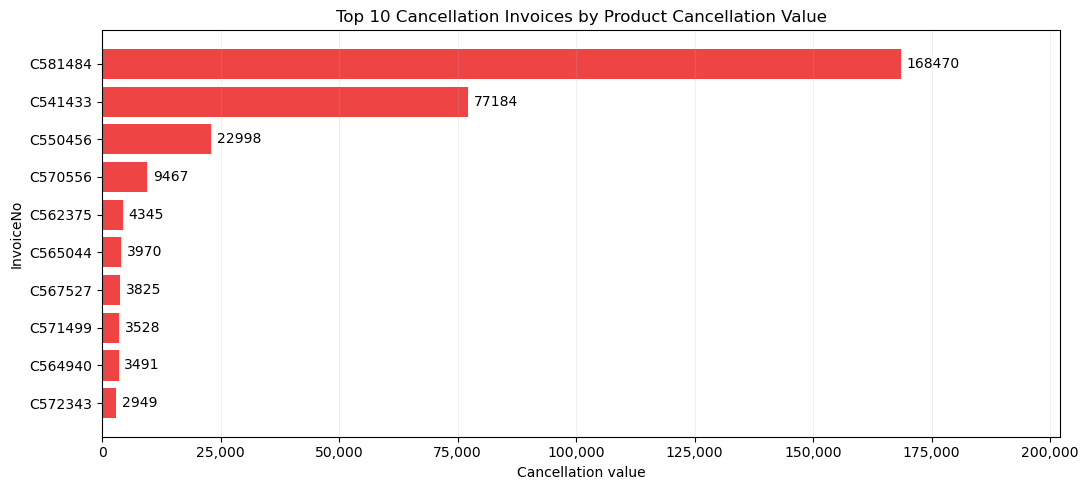

In [16]:
cancellation_invoices = (
    cancellations.groupby("InvoiceNo")
    .agg(
        InvoiceTimestamp=("InvoiceTimestamp", "min"),
        CustomerID=("CustomerID", "first"),
        Country=("Country", "first"),
        ProductLines=("SourceRowID", "size"),
        Products=("StockCode", "nunique"),
        CancelledUnits=("Quantity", lambda x: -x.sum()),
        CancellationValue=("Revenue", lambda x: -x.sum())
    )
    .sort_values("CancellationValue", ascending=False)
)

total_cancellation_value = cancellation_invoices["CancellationValue"].sum()

cancellation_invoices["ValueShare_pct"] = (
    cancellation_invoices["CancellationValue"]
    / total_cancellation_value
    * 100
)
cancellation_invoices["CumulativeValueShare_pct"] = (
    cancellation_invoices["ValueShare_pct"].cumsum()
)

assert len(cancellation_invoices) == cancellations["InvoiceNo"].nunique()
assert cancellation_invoices["ProductLines"].sum() == len(cancellations)

np.testing.assert_allclose(
    total_cancellation_value,
    monthly["CancellationValue"].sum(),
    rtol=0,
    atol=0.000001
)

display(cancellation_invoices.head(10))

print(
    "Top 2 cancellation invoices' value share: "
    f"{cancellation_invoices['ValueShare_pct'].head(2).sum():.2f}%"
)
print(
    "Top 10 cancellation invoices' value share: "
    f"{cancellation_invoices['ValueShare_pct'].head(10).sum():.2f}%"
)

top_cancellations = cancellation_invoices.head(10).sort_values(
    "CancellationValue"
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    top_cancellations.index,
    top_cancellations["CancellationValue"],
    color="#EF4444"
)

ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_xlim(0, top_cancellations["CancellationValue"].max() * 1.2)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Top 10 Cancellation Invoices by Product Cancellation Value")
ax.set_xlabel("Cancellation value")
ax.set_ylabel("InvoiceNo")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

In [17]:
largest_cancellation_ids = cancellation_invoices.head(2).index

largest_cancellation_lines = cancellations.loc[
    cancellations["InvoiceNo"].isin(largest_cancellation_ids),
    [
        "SourceRowID", "InvoiceNo", "CustomerID", "StockCode",
        "Quantity", "UnitPrice", "Revenue", "InvoiceDate"
    ]
].copy()

largest_cancellation_lines["MatchQuantity"] = (
    -largest_cancellation_lines["Quantity"]
)

sale_candidates = sales.loc[
    sales["CustomerID"].notna(),
    [
        "SourceRowID", "InvoiceNo", "CustomerID", "StockCode",
        "Quantity", "UnitPrice", "Revenue", "InvoiceDate"
    ]
].copy()

reversal_candidates = largest_cancellation_lines.merge(
    sale_candidates,
    left_on=["CustomerID", "StockCode", "UnitPrice", "MatchQuantity"],
    right_on=["CustomerID", "StockCode", "UnitPrice", "Quantity"],
    how="inner",
    suffixes=("_Cancellation", "_Sale")
)

reversal_candidates = reversal_candidates.loc[
    reversal_candidates["InvoiceDate_Sale"].le(
        reversal_candidates["InvoiceDate_Cancellation"]
    )
].copy()

reversal_candidates["MinutesToCancellation"] = (
    reversal_candidates["InvoiceDate_Cancellation"]
    - reversal_candidates["InvoiceDate_Sale"]
).dt.total_seconds() / 60

reversal_candidates["PairNetRevenue"] = (
    reversal_candidates["Revenue_Sale"]
    + reversal_candidates["Revenue_Cancellation"]
)

candidate_counts = reversal_candidates.groupby(
    "SourceRowID_Cancellation"
).size()

largest_cancellation_lines["CandidateSales"] = (
    largest_cancellation_lines["SourceRowID"]
    .map(candidate_counts)
    .fillna(0)
    .astype("int64")
)

display(
    largest_cancellation_lines[
        ["InvoiceNo", "SourceRowID", "StockCode", "CandidateSales"]
    ]
)

display(
    reversal_candidates[
        [
            "InvoiceNo_Sale", "InvoiceNo_Cancellation",
            "CustomerID", "StockCode",
            "Quantity_Sale", "Quantity_Cancellation", "UnitPrice",
            "Revenue_Sale", "Revenue_Cancellation",
            "MinutesToCancellation", "PairNetRevenue"
        ]
    ].sort_values(["InvoiceNo_Cancellation", "MinutesToCancellation"])
)

,InvoiceNo,SourceRowID,StockCode,CandidateSales
61624,C541433,61626,23166,1
540422,C581484,540424,23843,1


,InvoiceNo_Sale,InvoiceNo_Cancellation,CustomerID,StockCode,Quantity_Sale,Quantity_Cancellation,UnitPrice,Revenue_Sale,Revenue_Cancellation,MinutesToCancellation,PairNetRevenue
0,541431,C541433,12346,23166,74215,-74215,1.040,"77,183.600","-77,183.600",16.000,0.000
1,581483,C581484,16446,23843,80995,-80995,2.080,"168,469.600","-168,469.600",12.000,0.000


In [18]:
assert largest_cancellation_lines["CandidateSales"].eq(1).all()
assert reversal_candidates["SourceRowID_Sale"].is_unique
assert reversal_candidates["SourceRowID_Cancellation"].is_unique

np.testing.assert_allclose(
    reversal_candidates["PairNetRevenue"],
    0,
    rtol=0,
    atol=0.000001
)

reversal_row_ids = pd.Index(
    reversal_candidates[
        ["SourceRowID_Sale", "SourceRowID_Cancellation"]
    ].to_numpy().ravel()
).unique()

sensitivity_sales = sales.loc[
    ~sales["SourceRowID"].isin(reversal_row_ids)
].copy()

sensitivity_cancellations = cancellations.loc[
    ~cancellations["SourceRowID"].isin(reversal_row_ids)
].copy()

sensitivity_summary = pd.DataFrame({
    "All eligible transactions": {
        "GrossRevenue": sales["Revenue"].sum(),
        "CancellationValue": -cancellations["Revenue"].sum()
    },
    "Excluding two matched reversal pairs": {
        "GrossRevenue": sensitivity_sales["Revenue"].sum(),
        "CancellationValue": -sensitivity_cancellations["Revenue"].sum()
    }
}).T

sensitivity_summary["NetRevenue"] = (
    sensitivity_summary["GrossRevenue"]
    - sensitivity_summary["CancellationValue"]
)

sensitivity_summary["CancellationValueToGross_pct"] = (
    sensitivity_summary["CancellationValue"]
    / sensitivity_summary["GrossRevenue"]
    * 100
)

np.testing.assert_allclose(
    sensitivity_summary["NetRevenue"],
    revenue_check["Net product revenue"],
    rtol=0,
    atol=0.000001
)

sensitivity_monthly = monthly[
    ["GrossRevenue", "CancellationValue", "NetRevenue"]
].copy()

removed_sales = (
    sales.loc[sales["SourceRowID"].isin(reversal_row_ids)]
    .groupby("YearMonth")["Revenue"]
    .sum()
)

removed_cancellations = (
    -cancellations.loc[
        cancellations["SourceRowID"].isin(reversal_row_ids)
    ]
    .groupby("YearMonth")["Revenue"]
    .sum()
)

sensitivity_monthly["GrossWithoutPairs"] = (
    sensitivity_monthly["GrossRevenue"]
    - removed_sales.reindex(monthly.index, fill_value=0)
)

sensitivity_monthly["CancellationWithoutPairs"] = (
    sensitivity_monthly["CancellationValue"]
    - removed_cancellations.reindex(monthly.index, fill_value=0)
)

sensitivity_monthly["OriginalCancellationRatio_pct"] = (
    sensitivity_monthly["CancellationValue"]
    / sensitivity_monthly["GrossRevenue"]
    * 100
)

sensitivity_monthly["CancellationRatioWithoutPairs_pct"] = (
    sensitivity_monthly["CancellationWithoutPairs"]
    / sensitivity_monthly["GrossWithoutPairs"]
    * 100
)

np.testing.assert_allclose(
    sensitivity_monthly["GrossWithoutPairs"]
    - sensitivity_monthly["CancellationWithoutPairs"],
    sensitivity_monthly["NetRevenue"],
    rtol=0,
    atol=0.000001
)

display(sensitivity_summary)

display(
    sensitivity_monthly.loc[
        removed_sales.index.union(removed_cancellations.index),
        [
            "GrossRevenue", "GrossWithoutPairs",
            "CancellationValue", "CancellationWithoutPairs",
            "OriginalCancellationRatio_pct",
            "CancellationRatioWithoutPairs_pct", "NetRevenue"
        ]
    ]
)

print(f"Source rows in the two reversal pairs: {len(reversal_row_ids)}")
print("Net revenue unchanged: validation passed.")

,GrossRevenue,CancellationValue,NetRevenue,CancellationValueToGross_pct
All eligible transactions,"10,247,219.323","475,901.160","9,771,318.163",4.644
Excluding two matched reversal pairs,"10,001,566.123","230,247.960","9,771,318.163",2.302


,GrossRevenue,GrossWithoutPairs,CancellationValue,CancellationWithoutPairs,OriginalCancellationRatio_pct,CancellationRatioWithoutPairs_pct,NetRevenue
YearMonth,,,,,,,
2011-01,"670,380.240","593,196.640","91,525.050","14,341.450",13.653,2.418,"578,855.190"
2011-12,"614,490.920","446,021.320","174,091.360","5,621.760",28.331,1.260,"440,399.560"


Source rows in the two reversal pairs: 4
Net revenue unchanged: validation passed.


In [19]:
country_cancellation_review = country_summary[
    ["GrossRevenue", "CancellationValue", "NetRevenue", "Orders"]
].copy()

country_cancellation_review["CancellationInvoices"] = (
    cancellations.groupby("Country")["InvoiceNo"]
    .nunique()
    .reindex(country_cancellation_review.index, fill_value=0)
)

country_cancellation_review["CancellationValueToGross_pct"] = (
    country_cancellation_review["CancellationValue"]
    .div(country_cancellation_review["GrossRevenue"].replace(0, np.nan))
    .mul(100)
)

country_cancellation_review["CancellationDocumentShare_pct"] = (
    country_cancellation_review["CancellationInvoices"]
    .div(
        country_cancellation_review["Orders"]
        + country_cancellation_review["CancellationInvoices"]
    )
    .mul(100)
)

gross_without_pairs = (
    sensitivity_sales.groupby("Country")["Revenue"].sum()
    .reindex(country_cancellation_review.index, fill_value=0)
)

cancellation_without_pairs = (
    -sensitivity_cancellations.groupby("Country")["Revenue"].sum()
).reindex(country_cancellation_review.index, fill_value=0)

country_cancellation_review["GrossWithoutPairs"] = gross_without_pairs
country_cancellation_review["CancellationWithoutPairs"] = (
    cancellation_without_pairs
)

country_cancellation_review["CancellationRatioWithoutPairs_pct"] = (
    cancellation_without_pairs
    .div(gross_without_pairs.replace(0, np.nan))
    .mul(100)
)

country_cancellation_review["CancellationValueShare_pct"] = (
    country_cancellation_review["CancellationValue"]
    / country_cancellation_review["CancellationValue"].sum()
    * 100
)

np.testing.assert_allclose(
    gross_without_pairs - cancellation_without_pairs,
    country_cancellation_review["NetRevenue"],
    rtol=0,
    atol=0.000001
)

print("Top 10 markets by net product revenue")

display(
    country_cancellation_review.loc[
        country_summary.head(10).index,
        [
            "GrossRevenue", "CancellationValue",
            "CancellationValueShare_pct",
            "CancellationValueToGross_pct",
            "CancellationRatioWithoutPairs_pct",
            "Orders", "CancellationInvoices",
            "CancellationDocumentShare_pct"
        ]
    ]
)

print("Top 10 countries by cancellation value excluding the two pairs")

display(
    country_cancellation_review.sort_values(
        "CancellationWithoutPairs", ascending=False
    )[
        [
            "GrossWithoutPairs", "CancellationWithoutPairs",
            "CancellationRatioWithoutPairs_pct", "NetRevenue"
        ]
    ].head(10)
)

Top 10 markets by net product revenue


,GrossRevenue,CancellationValue,CancellationValueShare_pct,CancellationValueToGross_pct,CancellationRatioWithoutPairs_pct,Orders,CancellationInvoices,CancellationDocumentShare_pct
Country,,,,,,,,
United Kingdom,"8,724,443.673","443,053.310",93.098,5.078,2.328,17901,3029,14.472
Netherlands,"283,889.340",409.800,0.086,0.144,0.144,93,3,3.125
EIRE,"270,850.860","11,470.840",2.410,4.235,4.235,282,65,18.732
Germany,"205,381.150","4,761.490",1.001,2.318,2.318,443,135,23.356
France,"184,493.000","2,416.400",0.508,1.310,1.310,382,59,13.379
Australia,"138,103.810","1,181.310",0.248,0.855,0.855,56,11,16.418
Switzerland,"53,065.600",582.550,0.122,1.098,1.098,50,18,26.471
Spain,"55,706.560","3,959.910",0.832,7.109,7.109,88,12,12.000
Belgium,"36,927.340",264.380,0.056,0.716,0.716,98,19,16.239


Top 10 countries by cancellation value excluding the two pairs


,GrossWithoutPairs,CancellationWithoutPairs,CancellationRatioWithoutPairs_pct,NetRevenue
Country,,,,
United Kingdom,"8,478,790.473","197,400.110",2.328,"8,281,390.363"
EIRE,"270,850.860","11,470.840",4.235,"259,380.020"
Germany,"205,381.150","4,761.490",2.318,"200,619.660"
Spain,"55,706.560","3,959.910",7.109,"51,746.650"
France,"184,493.000","2,416.400",1.310,"182,076.600"
Japan,"37,416.370","1,996.580",5.336,"35,419.790"
USA,"3,580.390","1,849.470",51.656,"1,730.920"
Sweden,"36,828.830","1,662.420",4.514,"35,166.410"
Australia,"138,103.810","1,181.310",0.855,"136,922.500"


In [20]:
product_cancellation_review = product_summary[
    [
        "ProductDisplayName", "GrossRevenue",
        "CancellationValue", "NetRevenue", "OrdersContainingProduct"
    ]
].copy()

product_cancellation_review["CancellationInvoices"] = (
    cancellations.groupby("StockCode")["InvoiceNo"]
    .nunique()
    .reindex(product_cancellation_review.index, fill_value=0)
)

product_cancellation_review["CancellationValueToGross_pct"] = (
    product_cancellation_review["CancellationValue"]
    .div(product_cancellation_review["GrossRevenue"].replace(0, np.nan))
    .mul(100)
)

product_cancellation_review["GrossWithoutPairs"] = (
    sensitivity_sales.groupby("StockCode")["Revenue"]
    .sum()
    .reindex(product_cancellation_review.index, fill_value=0)
)

product_cancellation_review["CancellationWithoutPairs"] = (
    -sensitivity_cancellations.groupby("StockCode")["Revenue"].sum()
).reindex(product_cancellation_review.index, fill_value=0)

product_cancellation_review["CancellationRatioWithoutPairs_pct"] = (
    product_cancellation_review["CancellationWithoutPairs"]
    .div(
        product_cancellation_review["GrossWithoutPairs"]
        .replace(0, np.nan)
    )
    .mul(100)
)

np.testing.assert_allclose(
    product_cancellation_review["GrossWithoutPairs"]
    - product_cancellation_review["CancellationWithoutPairs"],
    product_cancellation_review["NetRevenue"],
    rtol=0,
    atol=0.000001
)

review_columns = [
    "ProductDisplayName", "GrossWithoutPairs",
    "CancellationWithoutPairs",
    "CancellationRatioWithoutPairs_pct",
    "OrdersContainingProduct", "CancellationInvoices", "NetRevenue"
]

print("Top 15 products by cancellation value excluding the two pairs")

display(
    product_cancellation_review.sort_values(
        "CancellationWithoutPairs", ascending=False
    )[review_columns].head(15)
)

print("Cancellation profile of the top 10 products by net revenue")

display(
    product_cancellation_review.loc[
        product_summary.head(10).index, review_columns
    ]
)

print("Products with cancellation value but no observed positive sales")

display(
    product_cancellation_review.loc[
        product_cancellation_review["GrossRevenue"].eq(0)
        & product_cancellation_review["CancellationValue"].gt(0),
        ["ProductDisplayName", "CancellationValue", "CancellationInvoices"]
    ].sort_values("CancellationValue", ascending=False)
)

Top 15 products by cancellation value excluding the two pairs


,ProductDisplayName,GrossWithoutPairs,CancellationWithoutPairs,CancellationRatioWithoutPairs_pct,OrdersContainingProduct,CancellationInvoices,NetRevenue
StockCode,,,,,,,
22423,REGENCY CAKESTAND 3 TIER,"174,156.540","9,697.050",5.568,"1,988.000",180,"164,459.490"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,462.750","6,624.300",6.341,"2,198.000",42,"97,838.450"
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,"18,056.280","6,591.420",36.505,262.000,3,"11,464.860"
23113,PANTRY CHOPPING BOARD,"5,868.500","4,803.060",81.845,57.000,6,"1,065.440"
48185,DOORMAT FAIRY CAKE,"23,872.910","4,554.900",19.080,365.000,3,"19,318.010"
21175,GIN + TONIC DIET METAL SIGN,"27,029.970","3,775.330",13.967,809.000,7,"23,254.640"
47566B,TEA TIME PARTY BUNTING,"11,275.270","3,692.950",32.753,365.000,7,"7,582.320"
22273,FELTCRAFT DOLL MOLLY,"12,001.590","3,512.650",29.268,331.000,5,"8,488.940"
71477,COLOUR GLASS. STAR T-LIGHT HOLDER,"20,650.660","3,443.620",16.676,316.000,31,"17,207.040"


Cancellation profile of the top 10 products by net revenue


,ProductDisplayName,GrossWithoutPairs,CancellationWithoutPairs,CancellationRatioWithoutPairs_pct,OrdersContainingProduct,CancellationInvoices,NetRevenue
StockCode,,,,,,,
22423,REGENCY CAKESTAND 3 TIER,"174,156.540","9,697.050",5.568,"1,988.000",180,"164,459.490"
47566,PARTY BUNTING,"99,445.230","1,201.350",1.208,"1,685.000",20,"98,243.880"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,462.750","6,624.300",6.341,"2,198.000",42,"97,838.450"
85099B,JUMBO BAG RED RETROSPOT,"94,159.810","1,984.020",2.107,"2,089.000",43,"92,175.790"
23084,RABBIT NIGHT LIGHT,"66,870.030",208.400,0.312,994.000,15,"66,661.630"
22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.590","1,160.350",1.789,"1,160.000",10,"63,715.240"
84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.620",135.200,0.229,"1,455.000",12,"58,792.420"
79321,CHILLI LIGHTS,"54,096.360",349.700,0.646,661.000,6,"53,746.660"
22502,PICNIC BASKET WICKER SMALL,"51,408.770",385.250,0.749,463.000,9,"51,023.520"


Products with cancellation value but no observed positive sales


,ProductDisplayName,CancellationValue,CancellationInvoices
StockCode,,,
79323W,WHITE CHERRY LIGHTS,54.000,1
85063,CREAM SWEETHEART MAGAZINE RACK,46.850,2
21645,ASSORTED TUTTI FRUTTI ROUND BOX,39.600,1
85042,ANTIQUE LILY FAIRY LIGHTS,14.850,2
85065,CREAM SWEETHEART TRAYS,12.750,1
37503,TEA TIME CAKE STAND IN GIFT BOX,10.750,1
85068,CREAM SWEETHEART SHELF + HOOKS,7.950,1
84839,SWEETHEART KEY CABINET,5.550,1
79320,FLAMINGO LIGHTS,4.950,1


In [21]:
product_invoice_cancellations = (
    sensitivity_cancellations.groupby(["StockCode", "InvoiceNo"])
    .agg(CancellationValue=("Revenue", lambda x: -x.sum()))
    .reset_index()
)

product_customer_cancellations = (
    sensitivity_cancellations.loc[
        sensitivity_cancellations["CustomerID"].notna()
    ]
    .groupby(["StockCode", "CustomerID"])
    .agg(CancellationValue=("Revenue", lambda x: -x.sum()))
    .reset_index()
)

largest_product_invoices = (
    product_invoice_cancellations
    .sort_values(
        ["CancellationValue", "InvoiceNo"],
        ascending=[False, True]
    )
    .drop_duplicates("StockCode")
    .set_index("StockCode")
    .rename(columns={
        "InvoiceNo": "LargestCancellationInvoice",
        "CancellationValue": "LargestInvoiceValue"
    })
)

largest_product_customers = (
    product_customer_cancellations
    .sort_values(
        ["CancellationValue", "CustomerID"],
        ascending=[False, True]
    )
    .drop_duplicates("StockCode")
    .set_index("StockCode")
    .rename(columns={
        "CustomerID": "LargestCancellationCustomer",
        "CancellationValue": "LargestCustomerValue"
    })
)

product_cancellation_concentration = (
    product_cancellation_review
    .join(largest_product_invoices)
    .join(largest_product_customers)
    .copy()
)

product_cancellation_concentration["LargestInvoiceShare_pct"] = (
    product_cancellation_concentration["LargestInvoiceValue"]
    .div(
        product_cancellation_concentration["CancellationWithoutPairs"]
        .replace(0, np.nan)
    )
    .mul(100)
)

product_cancellation_concentration["LargestKnownCustomerShare_pct"] = (
    product_cancellation_concentration["LargestCustomerValue"]
    .div(
        product_cancellation_concentration["CancellationWithoutPairs"]
        .replace(0, np.nan)
    )
    .mul(100)
)

np.testing.assert_allclose(
    product_invoice_cancellations["CancellationValue"].sum(),
    -sensitivity_cancellations["Revenue"].sum(),
    rtol=0,
    atol=0.000001
)

display(
    product_cancellation_concentration.sort_values(
        "CancellationWithoutPairs", ascending=False
    )[
        [
            "ProductDisplayName", "CancellationWithoutPairs",
            "CancellationRatioWithoutPairs_pct",
            "LargestCancellationInvoice", "LargestInvoiceValue",
            "LargestInvoiceShare_pct",
            "LargestCancellationCustomer",
            "LargestKnownCustomerShare_pct"
        ]
    ].head(10)
)

,ProductDisplayName,CancellationWithoutPairs,CancellationRatioWithoutPairs_pct,LargestCancellationInvoice,LargestInvoiceValue,LargestInvoiceShare_pct,LargestCancellationCustomer,LargestKnownCustomerShare_pct
StockCode,,,,,,,,
22423,REGENCY CAKESTAND 3 TIER,"9,697.050",5.568,C564081,"1,642.500",16.938,17949,16.938
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"6,624.300",6.341,C550456,"4,921.500",74.295,15749,74.295
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,"6,591.420",36.505,C550456,"6,539.400",99.211,15749,99.211
23113,PANTRY CHOPPING BOARD,"4,803.060",81.845,C567527,"3,825.360",79.644,17450,99.588
48185,DOORMAT FAIRY CAKE,"4,554.900",19.080,C550456,"4,522.500",99.289,15749,99.289
21175,GIN + TONIC DIET METAL SIGN,"3,775.330",13.967,C550456,"3,700.000",98.005,15749,98.005
47566B,TEA TIME PARTY BUNTING,"3,692.950",32.753,C550456,"3,315.000",89.766,15749,89.766
22273,FELTCRAFT DOLL MOLLY,"3,512.650",29.268,C570556,"3,492.000",99.412,16029,99.412
71477,COLOUR GLASS. STAR T-LIGHT HOLDER,"3,443.620",16.676,C556925,"1,155.000",33.540,16013,62.289


In [22]:
customer_cancellation_review = (
    sensitivity_sales.loc[sensitivity_sales["CustomerID"].notna()]
    .groupby("CustomerID")
    .agg(
        GrossRevenue=("Revenue", "sum"),
        PurchaseInvoices=("InvoiceNo", "nunique")
    )
    .join(
        sensitivity_cancellations.loc[
            sensitivity_cancellations["CustomerID"].notna()
        ]
        .groupby("CustomerID")
        .agg(
            CancellationValue=("Revenue", lambda x: -x.sum()),
            CancellationInvoices=("InvoiceNo", "nunique")
        ),
        how="outer"
    )
    .fillna(0)
)

customer_cancellation_review["NetRevenue"] = (
    customer_cancellation_review["GrossRevenue"]
    - customer_cancellation_review["CancellationValue"]
)

customer_cancellation_review["CancellationValueToGross_pct"] = (
    customer_cancellation_review["CancellationValue"]
    .div(customer_cancellation_review["GrossRevenue"].replace(0, np.nan))
    .mul(100)
)

remaining_cancellation_value = -sensitivity_cancellations["Revenue"].sum()

customer_cancellation_review["ShareOfAllCancellationValue_pct"] = (
    customer_cancellation_review["CancellationValue"]
    / remaining_cancellation_value
    * 100
)

customer_cancellation_review[
    ["PurchaseInvoices", "CancellationInvoices"]
] = customer_cancellation_review[
    ["PurchaseInvoices", "CancellationInvoices"]
].astype("int64")

customer_cancellation_review = customer_cancellation_review.sort_values(
    "CancellationValue", ascending=False
)

known_cancellation_value = customer_cancellation_review[
    "CancellationValue"
].sum()

missing_customer_cancellation_value = -sensitivity_cancellations.loc[
    sensitivity_cancellations["CustomerID"].isna(), "Revenue"
].sum()

np.testing.assert_allclose(
    known_cancellation_value + missing_customer_cancellation_value,
    remaining_cancellation_value,
    rtol=0,
    atol=0.000001
)

display(
    customer_cancellation_review.loc[
        customer_cancellation_review["CancellationValue"].gt(0)
    ].head(15)
)

display(
    pd.Series({
        "Remaining cancellation value": remaining_cancellation_value,
        "Known-customer cancellation value": known_cancellation_value,
        "Missing-customer cancellation value": missing_customer_cancellation_value,
        "Known-customer value coverage (%)": (
            known_cancellation_value / remaining_cancellation_value * 100
        ),
        "Top 5 customers' share of all cancellation value (%)": (
            customer_cancellation_review["CancellationValue"].head(5).sum()
            / remaining_cancellation_value
            * 100
        )
    }).to_frame("value")
)

,GrossRevenue,PurchaseInvoices,CancellationValue,CancellationInvoices,NetRevenue,CancellationValueToGross_pct,ShareOfAllCancellationValue_pct
CustomerID,,,,,,,
15749,"44,534.300",3,"22,998.400",1,"21,535.900",51.642,9.989
16029,"72,708.090",62,"12,338.160",4,"60,369.930",16.969,5.359
12931,"42,055.960",15,"8,511.150",4,"33,544.810",20.238,3.697
14911,"136,161.830",198,"7,393.590",44,"128,768.240",5.430,3.211
14607,"15,021.500",12,"5,228.400",3,"9,793.100",34.806,2.271
17450,"194,390.790",46,"4,815.260",3,"189,575.530",2.477,2.091
17949,"58,030.480",44,"4,814.740",5,"53,215.740",8.297,2.091
15482,"10,839.760",11,"4,486.240",4,"6,353.520",41.387,1.948
15769,"56,252.720",26,"4,429.000",3,"51,823.720",7.873,1.924


,value
Remaining cancellation value,"230,247.960"
Known-customer cancellation value,"226,097.510"
Missing-customer cancellation value,"4,150.450"
Known-customer value coverage (%),98.197
Top 5 customers' share of all cancellation value (%),24.526


In [23]:
identified_net_revenue = df.loc[
    df["IsNetProductRevenueEligible"] & df["HasCustomerID"],
    "Revenue"
].sum()

purchasing_customer_net = customer_metrics["MonetaryNet"].sum()

cancellation_only_value = customer_cancellations.loc[
    ~customer_cancellations["CustomerID"].isin(customer_metrics.index),
    "Revenue"
].sum()

analysis_checks = pd.Series({
    "Monthly net revenue reconciles": np.isclose(
        monthly["NetRevenue"].sum(),
        revenue_check["Net product revenue"],
        rtol=0, atol=0.000001
    ),
    "Country net revenue reconciles": np.isclose(
        country_summary["NetRevenue"].sum(),
        revenue_check["Net product revenue"],
        rtol=0, atol=0.000001
    ),
    "Product net revenue reconciles": np.isclose(
        product_summary["NetRevenue"].sum(),
        revenue_check["Net product revenue"],
        rtol=0, atol=0.000001
    ),
    "Customer net includes cancellation-only customers": np.isclose(
        purchasing_customer_net + cancellation_only_value,
        identified_net_revenue,
        rtol=0, atol=0.000001
    ),
    "Repeat groups cover all purchasing customers": (
        repeat_summary["Customers"].sum() == len(customer_metrics)
    ),
    "Segments cover all scored customers": (
        segment_summary["Customers"].sum() == len(rfm)
    ),
    "Segment net revenue reconciles": np.isclose(
        segment_summary["NetRevenue"].sum(),
        rfm["MonetaryNet"].sum(),
        rtol=0, atol=0.000001
    ),
    "Cohorts cover complete-month purchasing customers": (
        cohort_sizes.sum() == cohort_activity["CustomerID"].nunique()
    ),
    "Reversal sensitivity preserves net revenue": np.allclose(
        sensitivity_summary["NetRevenue"],
        revenue_check["Net product revenue"],
        rtol=0, atol=0.000001
    ),
    "Source rows retained": len(df) == 541909,
    "Source row identifiers unique": df["SourceRowID"].is_unique
})

display(analysis_checks.to_frame("passed"))

assert analysis_checks.all(), (
    f"Failed checks: {analysis_checks.index[~analysis_checks].tolist()}"
)

print("Analysis validation passed.")
print(f"Purchasing customers: {len(customer_metrics):,}")
print(f"Scored customers: {len(rfm):,}")
print(f"Identified net product revenue: {identified_net_revenue:,.3f}")
print(f"Cancellation-only customer net value: {cancellation_only_value:,.3f}")

,passed
Monthly net revenue reconciles,True
Country net revenue reconciles,True
Product net revenue reconciles,True
Customer net includes cancellation-only customers,True
Repeat groups cover all purchasing customers,True
Segments cover all scored customers,True
Segment net revenue reconciles,True
Cohorts cover complete-month purchasing customers,True
Reversal sensitivity preserves net revenue,True
Source rows retained,True


Analysis validation passed.
Purchasing customers: 4,334
Scored customers: 4,322
Identified net product revenue: 8,265,476.933
Cancellation-only customer net value: -3,922.980


In [29]:
ANALYSIS_DIR = PROCESSED_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

analysis_exports = {
    "monthly_revenue": monthly.rename_axis("YearMonth").reset_index(),
    "monthly_revenue_drivers": drivers.rename_axis("YearMonth").reset_index(),
    "country_summary": country_profile.rename_axis("Country").reset_index(),
    "product_summary": product_summary.rename_axis("StockCode").reset_index(),
    "product_pareto": pareto.rename_axis("StockCode").reset_index(),
    "customer_metrics": customer_metrics.rename_axis("CustomerID").reset_index(),
    "customer_segments": rfm_segmented.rename_axis("CustomerID").reset_index(),
    "customer_value_review": customer_value_review.rename_axis("CustomerID").reset_index(),
    "segment_summary": segment_summary.rename_axis("Segment").reset_index(),
    "repeat_purchase_summary": repeat_summary.rename_axis("PurchaseGroup").reset_index(),
    "cohort_retention": cohort_retention.rename_axis("CohortMonth").reset_index(),
    "cohort_sizes": cohort_sizes.rename("Customers").rename_axis("CohortMonth").reset_index(),
    "m1_retention": m1_summary.rename_axis("CohortMonth").reset_index(),
    "monthly_cancellations": cancellation_monthly.rename_axis("YearMonth").reset_index(),
    "cancellation_invoices": cancellation_invoices.rename_axis("InvoiceNo").reset_index(),
    "reversal_candidates": reversal_candidates.reset_index(drop=True),
    "reversal_sensitivity": sensitivity_summary.rename_axis("Scenario").reset_index(),
    "country_cancellations": country_cancellation_review.rename_axis("Country").reset_index(),
    "product_cancellations": product_cancellation_concentration.rename_axis("StockCode").reset_index(),
    "customer_cancellations": customer_cancellation_review.rename_axis("CustomerID").reset_index(),
    "analysis_validation": analysis_checks.rename("Passed").rename_axis("Check").reset_index()
}

export_manifest = []

for name, table in analysis_exports.items():
    export_table = table.copy().reset_index(drop=True)

    export_table.columns = pd.Index(
        [str(column) for column in export_table.columns],
        name=None
    )

    assert export_table.columns.is_unique, (
        f"Duplicate column names in {name}"
    )

    for column in export_table.columns:
        if isinstance(export_table[column].dtype, pd.PeriodDtype):
            export_table[column] = export_table[column].astype("string")

    output_path = ANALYSIS_DIR / f"{name}.csv"

    export_table.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    restored = pd.read_csv(
        output_path,
        dtype="string",
        encoding="utf-8-sig",
        keep_default_na=False
    )

    expected_text = export_table.astype("string").fillna("")

    pd.testing.assert_frame_equal(
        expected_text.reset_index(drop=True),
        restored.reset_index(drop=True),
        check_dtype=False,
        check_names=False,
        obj=f"CSV verification: {name}"
    )

    export_manifest.append({
        "File": output_path.name,
        "Rows": len(export_table),
        "Columns": export_table.shape[1],
        "SizeKB": output_path.stat().st_size / 1024,
        "Verified": True
    })

decision_log = """# Analysis Decision Log

- Original source rows are retained. Analytical scopes exclude flagged extra exact duplicates.
- Product revenue excludes shipping, fees, manual lines, discounts, vouchers and debt adjustments. It is not profit or total company revenue.
- Positive-price product sales and cancellation lines define gross and net product revenue.
- Missing CustomerID rows remain in revenue analysis and are excluded from customer analysis.
- December 2011 is partial and excluded from complete-month growth and retention comparisons.
- Revenue changes are decomposed into order-count and average-order-value contributions. These are descriptive contributions, not causal effects.
- RFM uses known purchasing customers with positive net value. Nonpositive-value customers are retained separately for review.
- RFM scores preserve ties using quartile thresholds. Segments are descriptive and are not predictions of churn.
- Purchase frequency and recency include observed purchase invoices, including purchases subsequently cancelled.
- Repeat purchase rate describes the observed period and differs from monthly retention.
- Cohorts use first observed purchase month. Earlier purchase history is unavailable.
- Retention measures activity in calendar months, allows returning after an inactive month, and leaves unavailable follow-up as missing.
- The weighted M1 baseline uses January to October 2011 cohorts. It is a historical comparison, not a causal benchmark.
- Product Pareto uses positive-net products. Zero and negative-net products remain in full reconciliation.
- Cancellation value divided by gross revenue is a period value ratio, not the probability that an original order was cancelled.
- Two uniquely matched sale/cancellation pairs are excluded only in sensitivity comparisons. Matching does not establish cancellation reasons.
- Removing both sides of these pairs leaves net revenue unchanged.
- Cancellation-only customers are included in identified net revenue reconciliation.
- High cancellation ratios are interpreted alongside absolute value, transaction count and customer concentration.
- No product defects, customer misconduct or repeated seasonal pattern are inferred from these data.
- CSV exports use the default numeric representation without display rounding. Identifier columns should be loaded as strings.
- CSV verification checks column labels and cell text. Axis metadata names are not stored in CSV.
"""

decision_log_path = ANALYSIS_DIR / "analysis_decision_log.md"
decision_log_path.write_text(decision_log, encoding="utf-8")

export_manifest = pd.DataFrame(export_manifest)

export_manifest.to_csv(
    ANALYSIS_DIR / "export_manifest.csv",
    index=False,
    encoding="utf-8-sig"
)

display(export_manifest)

print(f"Saved to: {ANALYSIS_DIR}")
print(f"Verified CSV tables: {len(export_manifest)}")
print(f"Decision log saved: {decision_log_path.name}")
print("All analysis CSV exports verified.")

,File,Rows,Columns,SizeKB,Verified
0,monthly_revenue.csv,13,8,1.175,True
1,monthly_revenue_drivers.csv,12,13,2.154,True
2,country_summary.csv,38,15,5.416,True
3,product_summary.csv,3922,9,318.383,True
4,product_pareto.csv,3899,12,472.138,True
5,customer_metrics.csv,4334,9,337.879,True
6,customer_segments.csv,4322,14,439.686,True
7,customer_value_review.csv,12,9,1.199,True
8,segment_summary.csv,6,8,0.627,True
9,repeat_purchase_summary.csv,2,8,0.309,True


Saved to: d:\project  whith Alex\E-Commerce Sales & Customer Analytics\data\processed\analysis
Verified CSV tables: 21
Decision log saved: analysis_decision_log.md
All analysis CSV exports verified.


In [27]:
    pd.testing.assert_frame_equal(
        expected_text.reset_index(drop=True),
        restored.reset_index(drop=True),
        check_dtype=False,
        check_names=False
    )